# AI proiect

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importuri

In [2]:
import zipfile
import random
import math
import re
import time
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

## Încărcare de date

In [3]:
def read_vrp_instances(zip_path):
    instances = {}

    with zipfile.ZipFile(zip_path, "r") as z:
        for filename in z.namelist():
            if not filename.endswith(".vrp"):
                continue

            with z.open(filename) as f:
                lines = f.read().decode("utf-8").splitlines()

            name = None
            capacity = None
            coords = {}
            demands = {}
            depot = None
            section = None

            for line in lines:
                line = line.strip()

                if line == "" or line == "EOF":
                    continue

                if line.startswith("NAME"):
                    name = line.split(":")[1].strip()

                elif line.startswith("CAPACITY"):
                    capacity = int(line.split(":")[1].strip())

                elif line == "NODE_COORD_SECTION":
                    section = "coords"

                elif line == "DEMAND_SECTION":
                    section = "demands"

                elif line == "DEPOT_SECTION":
                    section = "depot"

                elif section == "coords":
                    parts = line.split()
                    node = int(parts[0])
                    x = float(parts[1])
                    y = float(parts[2])
                    coords[node] = (x, y)

                elif section == "demands":
                    parts = line.split()
                    node = int(parts[0])
                    demand = int(parts[1])
                    demands[node] = demand

                elif section == "depot":
                    value = int(line)
                    if value != -1:
                        depot = value

            instances[name] = {
                "name": name,
                "capacity": capacity,
                "coords": coords,
                "demands": demands,
                "depot": depot
            }

    return instances

In [4]:
zip_file_path = "/content/drive/MyDrive/Colab Notebooks/A-VRP.zip"
instances = read_vrp_instances(zip_file_path)

instance = instances["A-n32-k5"]

print(instance["capacity"])
print(instance["coords"])
print(instance["demands"])
print(instance["depot"])

100
{1: (82.0, 76.0), 2: (96.0, 44.0), 3: (50.0, 5.0), 4: (49.0, 8.0), 5: (13.0, 7.0), 6: (29.0, 89.0), 7: (58.0, 30.0), 8: (84.0, 39.0), 9: (14.0, 24.0), 10: (2.0, 39.0), 11: (3.0, 82.0), 12: (5.0, 10.0), 13: (98.0, 52.0), 14: (84.0, 25.0), 15: (61.0, 59.0), 16: (1.0, 65.0), 17: (88.0, 51.0), 18: (91.0, 2.0), 19: (19.0, 32.0), 20: (93.0, 3.0), 21: (50.0, 93.0), 22: (98.0, 14.0), 23: (5.0, 42.0), 24: (42.0, 9.0), 25: (61.0, 62.0), 26: (9.0, 97.0), 27: (80.0, 55.0), 28: (57.0, 69.0), 29: (23.0, 15.0), 30: (20.0, 70.0), 31: (85.0, 60.0), 32: (98.0, 5.0)}
{1: 0, 2: 19, 3: 21, 4: 6, 5: 19, 6: 7, 7: 12, 8: 16, 9: 6, 10: 16, 11: 8, 12: 14, 13: 21, 14: 16, 15: 3, 16: 22, 17: 18, 18: 19, 19: 1, 20: 24, 21: 8, 22: 12, 23: 4, 24: 8, 25: 24, 26: 24, 27: 2, 28: 20, 29: 15, 30: 2, 31: 14, 32: 9}
1


## Tabu Search

### Formarea unei soluții, vecinătate și fitness

In [5]:
def get_vehicle_count_from_name(instance_name: str):
  """
  Extrage numarul de vehicule din numele instantei.
  Exemplu: A-n32-k5 -> 5.
  """
  match = re.search(r"-k(\d+)", instance_name)
  if match is None:
    raise ValueError("Nu pot extrage numarul de vehicule. Trimite vehicle_count manual.")
  return int(match.group(1))


def get_customers(coords: dict, depot: int):
  """
  Intoarce lista clientilor, fara depozit.
  """
  return [node for node in coords.keys() if node != depot]

def distance_matrix_CVRP(coords: dict):
  """
  Formarea matricei de distante pe baza coordonatelor citite din fisier.
  Distanta este euclidiana rotunjita.
  """
  dm = {}
  nodes = list(coords.keys())

  for i in nodes:
    dm[i] = {}
    for j in nodes:
      xd = coords[i][0] - coords[j][0]
      yd = coords[i][1] - coords[j][1]
      dm[i][j] = round(math.sqrt(xd ** 2 + yd ** 2)) #functie norma euclidiană
      dm[j][i] = dm[i][j] # asigurare că drumul întors e la fel de lung

  return dm

def copy_solution_CVRP(solution: list):
  """
  Copie profunda pentru o solutie CVRP.
  Solutia este lista de rute: [[clienti ruta 1], [clienti ruta 2], ...].
  """
  return [route[:] for route in solution]


def route_load(route: list, demands: dict):
  """
  Calculeaza cererea totala pentru o ruta.
  """
  return sum(demands[node] for node in route)

def is_valid_CVRP(solution: list, capacity: int, coords: dict, demands: dict,
                  depot: int, vehicle_count: int):
  """
  Verifica daca o solutie CVRP este valida:
  - nu foloseste mai multe vehicule decat sunt disponibile;
  - fiecare client apare exact o data;
  - fiecare ruta respecta capacitatea.
  """
  if len(solution) > vehicle_count:
    return False

  customers = get_customers(coords, depot)
  visited = []

  for route in solution:
    if route_load(route, demands) > capacity:
      return False

    for customer in route:
      if customer == depot or customer not in demands:
        return False
      visited.append(customer)

  if sorted(visited) != sorted(customers):
    return False

  return True

def generate_solution_CVRP(capacity, coords, demands, depot, vehicle_count):
    # Construim lista de clienti, eliminand depozitul deoarece rutele pornesc si se termina implicit in depot.
    customers = get_customers(coords, depot)

    # Verificam daca fiecare client poate fi servit de un vehicul.
    for customer in customers:
        if demands[customer] > capacity:
            raise ValueError("Exista un client cu cererea mai mare decat capacitatea vehiculului.")

    # Initializam direct numarul de rute egal cu numarul de vehicule disponibile.
    solution = [[] for _ in range(vehicle_count)]
    loads = [0 for _ in range(vehicle_count)]

    # Punem intai clientii cu cerere mai mare, ca sa evitam situatiile in care raman clienti greu de plasat la final.
    customers_order = customers[:]
    random.shuffle(customers_order)
    customers_order.sort(key=lambda customer: demands[customer], reverse=True)

    for customer in customers_order:
        demand = demands[customer]

        # Cautam rutele in care clientul incape fara sa depaseasca capacitatea.
        feasible_routes = []
        for route_index in range(vehicle_count):
            if loads[route_index] + demand <= capacity:
                feasible_routes.append(route_index)

        # Daca nu exista nicio ruta disponibila, instanta nu poate fi construita cu aceasta metoda simpla.
        if len(feasible_routes) == 0:
            raise ValueError("Nu s-a putut genera o solutie initiala valida pentru aceasta instanta.")

        # Alegem ruta care ramane cu cel mai putin spatiu liber dupa adaugare.
        # Astfel folosim mai eficient capacitatea vehiculelor si evitam recursia.
        best_route = feasible_routes[0]
        best_remaining_capacity = capacity - (loads[best_route] + demand)

        for route_index in feasible_routes:
            remaining_capacity = capacity - (loads[route_index] + demand)
            if remaining_capacity < best_remaining_capacity:
                best_route = route_index
                best_remaining_capacity = remaining_capacity

        solution[best_route].append(customer)
        loads[best_route] += demand

    # Amestecam ordinea clientilor din fiecare ruta pentru a pastra caracterul aleator al solutiei initiale.
    for route in solution:
        random.shuffle(route)

    return solution

def fitness_CVRP(solution, capacity, coords, demands, depot):
    total_distance = 0

    for route in solution:
      # Calculam incarcarea rutei pentru a verifica restrictia de capacitate.
        load = sum(demands[customer] for customer in route)

        # Penalizam solutiile invalide printr-o valoare foarte mare.
        if load > capacity:
            return float("inf")

        # fiecare ruta incepe si se termina in depozit.
        full_route = [depot] + route + [depot]

        # Calculam distanta rutei intre noduri consecutive.
        for i in range(len(full_route) - 1):
            node1 = full_route[i]
            node2 = full_route[i + 1]

            coord1 = coords[node1]
            coord2 = coords[node2]

            total_distance += math.sqrt(
                (coord1[0] - coord2[0]) ** 2 +
                (coord1[1] - coord2[1]) ** 2
            )

    return total_distance

def two_swap_CVRP(solution: list, capacity: int, coords: dict, demands: dict,
                  depot: int, vehicle_count: int, max_tries: int = 100):
  """
  Genereaza un vecin aleatoriu prin 2-swap.
  Se interschimba doi clienti, din aceeasi ruta sau din rute diferite.
  Dupa mutare verificam capacitatea.
  """
  # Salvam toate pozitiile clientilor din toate rutele.
  positions = []
  for route_index, route in enumerate(solution):
    for customer_index in range(len(route)):
      positions.append((route_index, customer_index))

  # Daca avem mai putin de doi clienti, nu se poate face 2-swap.
  if len(positions) < 2:
    return copy_solution_CVRP(solution)

  for _ in range(max_tries):
    # Lucram pe o copie pentru a nu modifica solutia initiala.
    x = copy_solution_CVRP(solution)
    # Alegem doua pozitii aleatoare, ca in 2-swap pentru TSP.
    (r1, p1), (r2, p2) = random.sample(positions, 2)
    # Interschimbam doi clienti, din aceeasi ruta sau din rute diferite.
    x[r1][p1], x[r2][p2] = x[r2][p2], x[r1][p1]

    # Pastram vecinul doar daca ramane o solutie valida.
    if is_valid_CVRP(x, capacity, coords, demands, depot, vehicle_count):
      return x

  # Daca nu se gaseste un vecin valid, returnam solutia initiala copiata.
  return copy_solution_CVRP(solution)


def two_opt_CVRP(solution: list, capacity: int, coords: dict, demands: dict,
                 depot: int, vehicle_count: int, max_tries: int = 100):
  """
  Genereaza un vecin aleatoriu prin 2-opt aplicat in interiorul unei rute.
  2-opt inverseaza un segment.
  Capacitatea nu se schimba, deoarece ruta contine aceiasi clienti.
  """
  # Verificam daca avem rute care au cel putin doi clienti.
  eligible_routes = []
  for route_index, route in enumerate(solution):
    if len(route) >= 2:
      eligible_routes.append(route_index)

  if len(eligible_routes) == 0:
    return copy_solution_CVRP(solution)

  for _ in range(max_tries):
    # Copiem solutia pentru a genera un vecin fara a modifica solutia curenta.
    x = copy_solution_CVRP(solution)
    route_index = random.choice(eligible_routes)
    route_length = len(x[route_index])

    # Alegem o ruta si doua pozitii din ruta.
    i = random.randint(0, route_length - 2)
    j = random.randint(i + 1, route_length - 1)
    # Inversam segmentul dintre cele doua pozitii.
    x[route_index][i:j + 1] = reversed(x[route_index][i:j + 1])

    # Solutia ramane valida daca fiecare client apare o singura data si capacitatea este respectata.
    if is_valid_CVRP(x, capacity, coords, demands, depot, vehicle_count):
      return x

  return copy_solution_CVRP(solution)

def generate_neighbor_CVRP(solution: list, capacity: int, coords: dict, demands: dict,
                           depot: int, vehicle_count: int, neighborhood_type: str = "2-swap"):
  """
  Genereaza un vecin CVRP folosind vecinatatea ceruta, ca in A2.
  neighborhood_type poate fi doar "2-swap" sau "2-opt".
  """
  if neighborhood_type == "2-swap":
    return two_swap_CVRP(solution, capacity, coords, demands, depot, vehicle_count)

  if neighborhood_type == "2-opt":
    return two_opt_CVRP(solution, capacity, coords, demands, depot, vehicle_count)

  raise ValueError("neighborhood_type trebuie sa fie '2-swap' sau '2-opt'")

def all_neighbors_CVRP(solution: list, capacity: int, coords: dict, demands: dict,
                       depot: int, vehicle_count: int, neighborhood_type: str = "2-swap"):
  """
  Genereaza toti vecinii unei solutii CVRP si mutarea asociata.
  Pentru TS, mutarea este memorata in tabu.
  neighborhood_type poate fi doar "2-swap" sau "2-opt".
  """
  # Lista va contine perechi de forma: vecin + mutarea care a generat vecinul.
  neighbors = []

  if neighborhood_type == "2-swap":
    # Construim toate pozitiile posibile ale clientilor din toate rutele.
    positions = []
    for route_index, route in enumerate(solution):
      for customer_index in range(len(route)):
        positions.append((route_index, customer_index))

    # Generam toti vecinii obtinuti prin schimbarea a doi clienti.
    for a in range(len(positions) - 1):
      for b in range(a + 1, len(positions)):
        r1, p1 = positions[a]
        r2, p2 = positions[b]

        customer_1 = solution[r1][p1]
        customer_2 = solution[r2][p2]

        x = copy_solution_CVRP(solution)
        x[r1][p1], x[r2][p2] = x[r2][p2], x[r1][p1]

        if is_valid_CVRP(x, capacity, coords, demands, depot, vehicle_count):
          # Memoram mutarea pentru lista tabu.
          move = ("2-swap", min(customer_1, customer_2), max(customer_1, customer_2))
          neighbors.append((x, move))

  elif neighborhood_type == "2-opt":
    # Generam toti vecinii obtinuti prin inversarea unui segment dintr-o ruta.
    for route_index, route in enumerate(solution):
      if len(route) < 2:
        continue

      for i in range(len(route) - 1):
        for j in range(i + 1, len(route)):
          x = copy_solution_CVRP(solution)
          customer_1 = x[route_index][i]
          customer_2 = x[route_index][j]
          x[route_index][i:j + 1] = reversed(x[route_index][i:j + 1])

          if is_valid_CVRP(x, capacity, coords, demands, depot, vehicle_count):
            # Mutarea retine tipul vecinatatii, ruta si clientii care delimiteaza inversarea.
            move = ("2-opt", route_index, min(customer_1, customer_2), max(customer_1, customer_2))
            neighbors.append((x, move))

  else:
    raise ValueError("neighborhood_type trebuie sa fie '2-swap' sau '2-opt'")

  return neighbors


Algoritm Tabu Search

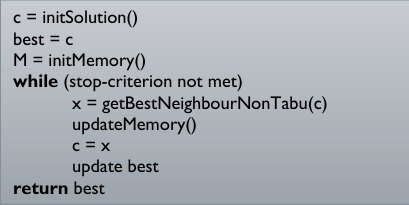

In [6]:
def tabu_search_CVRP(max_iterations: int, tabu_tenure: int,
                     capacity: int, coords: dict, demands: dict, depot: int,
                     vehicle_count: int, neighborhood_type: str = "2-swap"):
  # Generam solutia initiala valida pentru CVRP.
  c = generate_solution_CVRP(capacity, coords, demands, depot, vehicle_count)
  # Evaluam solutia curenta.
  fc = fitness_CVRP(c, capacity, coords, demands, depot)
  # Initial, cea mai buna solutie este chiar solutia curenta.
  best = copy_solution_CVRP(c)
  fbest = fc
  # Lista tabu retine mutarile interzise temporar.
  tabu = {}
  # found_solutions retine evolutia solutiei curente.
  found_solutions = [fc]
  # best_history retine evolutia celei mai bune solutii gasite.
  best_history = [fbest]

  for _ in range(max_iterations):
    # Generam toti vecinii solutiei curente folosind 2-swap sau 2-opt.
    neighbors = all_neighbors_CVRP(c, capacity, coords, demands, depot, vehicle_count, neighborhood_type)

    candidate = None
    candidate_move = None
    candidate_fitness = float("inf")

    for x, move in neighbors:
      # Evaluam fiecare vecin.
      fx = fitness_CVRP(x, capacity, coords, demands, depot)
      # Verificam daca mutarea este in lista tabu.
      is_tabu = move in tabu and tabu[move] > 0
      # Criteriu de aspiratie: acceptam o mutare tabu daca imbunatateste cea mai buna solutie globala.
      aspiration = fx < fbest

      # Alegem cel mai bun vecin care nu este tabu sau care respecta criteriul de aspiratie.
      if (not is_tabu or aspiration) and fx < candidate_fitness:
        candidate = copy_solution_CVRP(x)
        candidate_move = move
        candidate_fitness = fx

    # Daca nu exista niciun vecin acceptabil, oprim cautarea.
    if candidate is None:
      break

    # Scadem durata ramasa pentru fiecare mutare tabu.
    for move in list(tabu.keys()):
      tabu[move] -= 1
      # Eliminam mutarile care nu mai sunt tabu.
      if tabu[move] <= 0:
        del tabu[move]

    # Adaugam mutarea aleasa in lista tabu pentru tabu_tenure iteratii.
    tabu[candidate_move] = tabu_tenure

    # Actualizam solutia curenta cu cel mai bun vecin acceptat.
    c = copy_solution_CVRP(candidate)
    fc = candidate_fitness
    found_solutions.append(fc)

    # Actualizam cea mai buna solutie globala daca am gasit o imbunatatire.
    if fc < fbest:
      best = copy_solution_CVRP(c)
      fbest = fc

    best_history.append(fbest)

  return best, fbest, found_solutions, best_history

## Experimente Tabu Search


In [7]:
def run_algorithm_n_times(algorithm, n: int, *args):
  """
  Ruleaza un algoritm de n ori si returneaza rezultatele si timpul mediu.
  """
  results = []
  average_time = 0

  for _ in range(n):
    start = time.time()
    result = algorithm(*args)
    stop = time.time() - start

    average_time += stop
    results.append(result)

  average_time /= n
  return results, average_time


def plot_history(history: list, title: str, ylabel: str):
  """
  Afiseaza evolutia unei valori pe parcursul iteratiilor.
  """
  plt.figure(figsize=(10, 5))
  plt.plot(history)
  plt.title(title)
  plt.xlabel("Iteratia")
  plt.ylabel(ylabel)
  plt.grid()
  plt.show()


def plot_multiple_histories(histories: dict, title: str, ylabel: str):
  """
  Afiseaza pe acelasi grafic mai multe evolutii, de exemplu 2-swap vs 2-opt.
  """
  plt.figure(figsize=(10, 5))

  for label, history in histories.items():
    plt.plot(history, label=label)

  plt.title(title)
  plt.xlabel("Iteratia")
  plt.ylabel(ylabel)
  plt.legend()
  plt.grid()
  plt.show()


def solution_loads_CVRP(solution: list, demands: dict):
  """
  Intoarce incarcarea fiecarei rute.
  """
  return [route_load(route, demands) for route in solution]


def used_vehicles_CVRP(solution: list):
  """
  Numarul de vehicule folosite, adica rutele care au cel putin un client.
  """
  return sum(1 for route in solution if len(route) > 0)


def plot_route_loads_CVRP(solution: list, demands: dict, capacity: int, title: str):
  """
  Grafic pentru incarcarea fiecarei rute fata de capacitatea maxima.
  """
  loads = solution_loads_CVRP(solution, demands)
  route_labels = [f"R{i + 1}" for i in range(len(loads))]

  plt.figure(figsize=(10, 5))
  plt.bar(route_labels, loads)
  plt.axhline(capacity, linestyle="--", label="Capacitate")
  plt.title(title)
  plt.xlabel("Ruta")
  plt.ylabel("Cerere totala")
  plt.legend()
  plt.grid(axis="y")
  plt.show()


def plot_solution_CVRP(solution: list, coords: dict, depot: int, title: str):
  """
  Afiseaza grafic rutele dintr-o solutie CVRP.
  Depozitul este desenat separat, iar fiecare ruta pleaca din depot si revine in depot.
  """
  plt.figure(figsize=(8, 8))

  # clientii
  customers = [node for node in coords.keys() if node != depot]
  x_customers = [coords[node][0] for node in customers]
  y_customers = [coords[node][1] for node in customers]
  plt.scatter(x_customers, y_customers, label="Clienti")

  # depozitul
  plt.scatter([coords[depot][0]], [coords[depot][1]], marker="s", s=120, label="Depot")

  # rutele
  for route_index, route in enumerate(solution):
    if len(route) == 0:
      continue

    full_route = [depot] + route + [depot]
    x_route = [coords[node][0] for node in full_route]
    y_route = [coords[node][1] for node in full_route]
    plt.plot(x_route, y_route, marker="o", label=f"Ruta {route_index + 1}")

  # etichete pentru noduri
  for node, (x, y) in coords.items():
    plt.text(x, y, str(node), fontsize=8)

  plt.title(title)
  plt.xlabel("x")
  plt.ylabel("y")
  plt.legend()
  plt.grid()
  plt.show()


def plot_cvrp_experiment_metric(rows: list, metric_key: str, title: str, ylabel: str):
  """
  Grafic de tip bar pentru un indicator din tabelul de experimente.
  """
  labels = []
  values = []

  for row in rows:
    label = f"{row['pi']}\n{row['neighborhood']}\nit={row['max_iterations']}, tabu={row['tabu_tenure']}"
    labels.append(label)
    values.append(row[metric_key])

  plt.figure(figsize=(max(10, len(rows) * 1.2), 5))
  plt.bar(labels, values)
  plt.title(title)
  plt.xlabel("Experiment")
  plt.ylabel(ylabel)
  plt.xticks(rotation=45, ha="right")
  plt.grid(axis="y")
  plt.tight_layout()
  plt.show()


In [8]:
def run_cvrp_tabu_experiments(instances: dict,
                              problem_names: list,
                              ts_params_list: list,
                              neighborhood_types: list = ["2-swap", "2-opt"],
                              n_runs: int = 3):
  """
  Ruleaza experimente pentru Tabu Search CVRP si intoarce o lista de dictionare.
  """
  rows = []

  for pi in problem_names:
    instance = instances[pi]

    capacity = instance["capacity"]
    coords = instance["coords"]
    demands = instance["demands"]
    depot = instance["depot"]
    vehicle_count = get_vehicle_count_from_name(pi)

    for neighborhood_type in neighborhood_types:
      for params in ts_params_list:
        results, avg_time = run_algorithm_n_times(
            tabu_search_CVRP,
            n_runs,
            params["max_iterations"],
            params["tabu_tenure"],
            capacity,
            coords,
            demands,
            depot,
            vehicle_count,
            neighborhood_type
        )

        best_result = min(results, key=lambda item: item[1])
        worst_result = max(results, key=lambda item: item[1])
        avg_fitness = sum(item[1] for item in results) / len(results)

        best_solution = best_result[0]
        loads = solution_loads_CVRP(best_solution, demands)
        used_vehicles = used_vehicles_CVRP(best_solution)
        max_load = max(loads) if len(loads) > 0 else 0
        avg_load = sum(loads) / used_vehicles if used_vehicles > 0 else 0

        rows.append({
            "pi": pi,
            "n_runs": n_runs,
            "algorithm": "TS",
            "neighborhood": neighborhood_type,
            "max_iterations": params["max_iterations"],
            "tabu_tenure": params["tabu_tenure"],
            "best_fitness": best_result[1],
            "avg_fitness": avg_fitness,
            "worst_fitness": worst_result[1],
            "avg_time": avg_time,
            "used_vehicles": used_vehicles,
            "max_load": max_load,
            "avg_load": avg_load,
            "best_solution": best_solution,
            "best_history": best_result[3],
            "found_solutions": best_result[2]
        })

  return rows


def cvrp_experiments_to_markdown(rows: list):
  """
  Construieste tabel.
  """
  markdown_table = "| pi | n | Algorithm | Neighborhood | max_iterations | tabu_tenure | Best Distance | Avg Distance | Worst Distance | Avg Time | Used Vehicles | Max Load | Avg Load |\n"
  markdown_table += "|---|---|---|---|---|---|---|---|---|---|---|---|---|\n"

  for row in rows:
    markdown_table += (
        f"| {row['pi']} "
        f"| {row['n_runs']} "
        f"| {row['algorithm']} "
        f"| {row['neighborhood']} "
        f"| {row['max_iterations']} "
        f"| {row['tabu_tenure']} "
        f"| {row['best_fitness']:.2f} "
        f"| {row['avg_fitness']:.2f} "
        f"| {row['worst_fitness']:.2f} "
        f"| {row['avg_time']:.4f} "
        f"| {row['used_vehicles']} "
        f"| {row['max_load']} "
        f"| {row['avg_load']:.2f} |\n"
    )

  return markdown_table


def display_markdown_table(markdown_table: str):
  """
  Afiseaza tabelul.
  """
  try:
    display(Markdown(markdown_table))
  except Exception:
    print(markdown_table)


def best_rows_per_instance(rows: list):
  """
  Intoarce cea mai buna configuratie pentru fiecare instanta.
  Comparatia se face dupa Best Distance, deoarece CVRP este problema de minimizare.
  """
  best_rows = {}

  for row in rows:
    pi = row["pi"]
    if pi not in best_rows or row["best_fitness"] < best_rows[pi]["best_fitness"]:
      best_rows[pi] = row

  return [best_rows[pi] for pi in sorted(best_rows.keys())]


def best_rows_per_instance_and_neighborhood(rows: list):
  """
  Pentru fiecare instanta si fiecare vecinatate, intoarce cea mai buna configuratie.
  Este util pentru comparatia directa 2-swap vs 2-opt pe toate instantele.
  """
  best_rows = {}

  for row in rows:
    key = (row["pi"], row["neighborhood"])
    if key not in best_rows or row["best_fitness"] < best_rows[key]["best_fitness"]:
      best_rows[key] = row

  return [best_rows[key] for key in sorted(best_rows.keys())]


def best_rows_to_markdown(rows: list):
  """
  Tabel Markdown cu cea mai buna configuratie gasita pentru fiecare instanta.
  """
  best_rows = best_rows_per_instance(rows)

  markdown_table = "| pi | Best Neighborhood | max_iterations | tabu_tenure | Best Distance | Avg Distance | Avg Time | Used Vehicles | Max Load | Avg Load |\n"
  markdown_table += "|---|---|---|---|---|---|---|---|---|---|\n"

  for row in best_rows:
    markdown_table += (
        f"| {row['pi']} "
        f"| {row['neighborhood']} "
        f"| {row['max_iterations']} "
        f"| {row['tabu_tenure']} "
        f"| {row['best_fitness']:.2f} "
        f"| {row['avg_fitness']:.2f} "
        f"| {row['avg_time']:.4f} "
        f"| {row['used_vehicles']} "
        f"| {row['max_load']} "
        f"| {row['avg_load']:.2f} |\n"
    )

  return markdown_table


def neighborhood_summary_to_markdown(rows: list):
  """
  Tabel Markdown care rezuma performanta vecinatatilor pe toate instantele.
  """
  best_by_instance = best_rows_per_instance(rows)
  best_by_instance_neighborhood = best_rows_per_instance_and_neighborhood(rows)
  neighborhoods = sorted(set(row["neighborhood"] for row in rows))

  markdown_table = "| Neighborhood | Wins | Avg Best Distance | Avg Time | Avg Used Vehicles |\n"
  markdown_table += "|---|---|---|---|---|\n"

  for neighborhood in neighborhoods:
    rows_n = [row for row in best_by_instance_neighborhood if row["neighborhood"] == neighborhood]
    wins = sum(1 for row in best_by_instance if row["neighborhood"] == neighborhood)
    avg_best_distance = sum(row["best_fitness"] for row in rows_n) / len(rows_n)
    avg_time = sum(row["avg_time"] for row in rows_n) / len(rows_n)
    avg_used_vehicles = sum(row["used_vehicles"] for row in rows_n) / len(rows_n)

    markdown_table += (
        f"| {neighborhood} "
        f"| {wins} "
        f"| {avg_best_distance:.2f} "
        f"| {avg_time:.4f} "
        f"| {avg_used_vehicles:.2f} |\n"
    )

  return markdown_table


def plot_best_distance_per_instance(rows: list):
  """
  Grafic cu cea mai buna distanta obtinuta pentru fiecare instanta.
  Se foloseste cea mai buna configuratie gasita in tabel.
  """
  best_rows = best_rows_per_instance(rows)
  labels = [row["pi"] for row in best_rows]
  values = [row["best_fitness"] for row in best_rows]

  plt.figure(figsize=(max(12, len(labels) * 0.5), 5))
  plt.bar(labels, values)
  plt.title("CVRP - cea mai buna distanta pentru fiecare instanta")
  plt.xlabel("Instanta")
  plt.ylabel("Best distance")
  plt.xticks(rotation=60, ha="right")
  plt.grid(axis="y")
  plt.tight_layout()
  plt.show()


def plot_best_distance_by_neighborhood(rows: list):
  """
  Grafic comparativ: pentru fiecare instanta se afiseaza cea mai buna valoare obtinuta cu 2-swap si 2-opt.
  """
  grouped_rows = best_rows_per_instance_and_neighborhood(rows)
  labels = []
  values = []

  for row in grouped_rows:
    labels.append(f"{row['pi']}\n{row['neighborhood']}")
    values.append(row["best_fitness"])

  plt.figure(figsize=(max(12, len(labels) * 0.35), 5))
  plt.bar(labels, values)
  plt.title("CVRP - comparatie 2-swap vs 2-opt pe fiecare instanta")
  plt.xlabel("Instanta si vecinatate")
  plt.ylabel("Best distance")
  plt.xticks(rotation=60, ha="right")
  plt.grid(axis="y")
  plt.tight_layout()
  plt.show()


def plot_neighborhood_wins(rows: list):
  """
  Grafic cu numarul de instante castigate de fiecare vecinatate.
  O vecinatate castiga o instanta daca are cea mai mica Best Distance pe acea instanta.
  """
  best_rows = best_rows_per_instance(rows)
  neighborhoods = sorted(set(row["neighborhood"] for row in rows))
  wins = []

  for neighborhood in neighborhoods:
    wins.append(sum(1 for row in best_rows if row["neighborhood"] == neighborhood))

  plt.figure(figsize=(7, 5))
  plt.bar(neighborhoods, wins)
  plt.title("CVRP - numar de instante castigate de fiecare vecinatate")
  plt.xlabel("Vecinatate")
  plt.ylabel("Numar instante")
  plt.grid(axis="y")
  plt.show()


def plot_average_time_by_neighborhood(rows: list):
  """
  Grafic cu timpul mediu al celor mai bune configuratii pentru fiecare vecinatate.
  """
  grouped_rows = best_rows_per_instance_and_neighborhood(rows)
  neighborhoods = sorted(set(row["neighborhood"] for row in rows))
  avg_times = []

  for neighborhood in neighborhoods:
    rows_n = [row for row in grouped_rows if row["neighborhood"] == neighborhood]
    avg_times.append(sum(row["avg_time"] for row in rows_n) / len(rows_n))

  plt.figure(figsize=(7, 5))
  plt.bar(neighborhoods, avg_times)
  plt.title("CVRP - timpul mediu pe vecinatate")
  plt.xlabel("Vecinatate")
  plt.ylabel("Avg time")
  plt.grid(axis="y")
  plt.show()


Rulare experimente si afisare rezultate


In [9]:
ts_params_list = [
  {"max_iterations": 20, "tabu_tenure": 2},
  {"max_iterations": 30, "tabu_tenure": 3},
  {"max_iterations": 50, "tabu_tenure": 5},
]

# Comparam toate instantele citite din fisierul A-VRP.zip.
all_problem_names_CVRP = sorted(instances.keys())
problem_names_CVRP = all_problem_names_CVRP

print("Instante comparate:", problem_names_CVRP)

experiment_rows = run_cvrp_tabu_experiments(
    instances,
    problem_names_CVRP,
    ts_params_list,
    neighborhood_types=["2-swap", "2-opt"],
    n_runs=3
)

# Tabel detaliat: toate instantele, toate vecinatatile si toate combinatiile de parametri.
markdown_table_cvrp = cvrp_experiments_to_markdown(experiment_rows)
print(markdown_table_cvrp)
display_markdown_table(markdown_table_cvrp)

# Tabel rezumat: cea mai buna configuratie pentru fiecare instanta.
markdown_best_per_instance = best_rows_to_markdown(experiment_rows)
print(markdown_best_per_instance)
display_markdown_table(markdown_best_per_instance)

# Tabel rezumat: comparatie generala intre 2-swap si 2-opt.
markdown_neighborhood_summary = neighborhood_summary_to_markdown(experiment_rows)
print(markdown_neighborhood_summary)
display_markdown_table(markdown_neighborhood_summary)


Instante comparate: ['A-n32-k5', 'A-n33-k5', 'A-n33-k6', 'A-n34-k5', 'A-n36-k5', 'A-n37-k5', 'A-n37-k6', 'A-n38-k5', 'A-n39-k5', 'A-n39-k6', 'A-n44-k6', 'A-n45-k6', 'A-n45-k7', 'A-n46-k7', 'A-n48-k7', 'A-n53-k7', 'A-n54-k7', 'A-n55-k9', 'A-n60-k9', 'A-n61-k9', 'A-n62-k8', 'A-n63-k10', 'A-n63-k9', 'A-n64-k9', 'A-n65-k9', 'A-n69-k9', 'A-n80-k10']
| pi | n | Algorithm | Neighborhood | max_iterations | tabu_tenure | Best Distance | Avg Distance | Worst Distance | Avg Time | Used Vehicles | Max Load | Avg Load |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| A-n32-k5 | 3 | TS | 2-swap | 20 | 2 | 1013.50 | 1074.45 | 1122.38 | 0.1544 | 5 | 100 | 82.00 |
| A-n32-k5 | 3 | TS | 2-swap | 30 | 3 | 1096.36 | 1138.07 | 1166.62 | 0.2289 | 5 | 100 | 82.00 |
| A-n32-k5 | 3 | TS | 2-swap | 50 | 5 | 1019.40 | 1077.05 | 1180.36 | 0.6368 | 5 | 100 | 82.00 |
| A-n32-k5 | 3 | TS | 2-opt | 20 | 2 | 1313.74 | 1343.81 | 1365.92 | 0.0396 | 5 | 100 | 82.00 |
| A-n32-k5 | 3 | TS | 2-opt | 30 | 3 | 1351.77

| pi | n | Algorithm | Neighborhood | max_iterations | tabu_tenure | Best Distance | Avg Distance | Worst Distance | Avg Time | Used Vehicles | Max Load | Avg Load |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| A-n32-k5 | 3 | TS | 2-swap | 20 | 2 | 1013.50 | 1074.45 | 1122.38 | 0.1544 | 5 | 100 | 82.00 |
| A-n32-k5 | 3 | TS | 2-swap | 30 | 3 | 1096.36 | 1138.07 | 1166.62 | 0.2289 | 5 | 100 | 82.00 |
| A-n32-k5 | 3 | TS | 2-swap | 50 | 5 | 1019.40 | 1077.05 | 1180.36 | 0.6368 | 5 | 100 | 82.00 |
| A-n32-k5 | 3 | TS | 2-opt | 20 | 2 | 1313.74 | 1343.81 | 1365.92 | 0.0396 | 5 | 100 | 82.00 |
| A-n32-k5 | 3 | TS | 2-opt | 30 | 3 | 1351.77 | 1356.52 | 1359.28 | 0.0594 | 5 | 100 | 82.00 |
| A-n32-k5 | 3 | TS | 2-opt | 50 | 5 | 1356.71 | 1359.02 | 1361.08 | 0.1053 | 5 | 100 | 82.00 |
| A-n33-k5 | 3 | TS | 2-swap | 20 | 2 | 830.00 | 856.38 | 897.38 | 0.1879 | 5 | 100 | 89.20 |
| A-n33-k5 | 3 | TS | 2-swap | 30 | 3 | 802.06 | 829.98 | 857.34 | 0.2893 | 5 | 96 | 89.20 |
| A-n33-k5 | 3 | TS | 2-swap | 50 | 5 | 813.50 | 825.91 | 837.98 | 0.4672 | 5 | 99 | 89.20 |
| A-n33-k5 | 3 | TS | 2-opt | 20 | 2 | 1161.90 | 1199.92 | 1244.78 | 0.0402 | 5 | 100 | 89.20 |
| A-n33-k5 | 3 | TS | 2-opt | 30 | 3 | 1164.25 | 1200.06 | 1247.87 | 0.0636 | 5 | 100 | 89.20 |
| A-n33-k5 | 3 | TS | 2-opt | 50 | 5 | 1232.39 | 1253.67 | 1268.86 | 0.1033 | 5 | 100 | 89.20 |
| A-n33-k6 | 3 | TS | 2-swap | 20 | 2 | 893.49 | 951.32 | 1001.80 | 0.1602 | 6 | 100 | 90.17 |
| A-n33-k6 | 3 | TS | 2-swap | 30 | 3 | 871.94 | 917.64 | 955.71 | 0.3710 | 6 | 99 | 90.17 |
| A-n33-k6 | 3 | TS | 2-swap | 50 | 5 | 841.18 | 879.62 | 913.10 | 0.6479 | 6 | 99 | 90.17 |
| A-n33-k6 | 3 | TS | 2-opt | 20 | 2 | 1172.55 | 1208.50 | 1239.83 | 0.0326 | 6 | 100 | 90.17 |
| A-n33-k6 | 3 | TS | 2-opt | 30 | 3 | 1171.37 | 1220.82 | 1252.92 | 0.0545 | 6 | 100 | 90.17 |
| A-n33-k6 | 3 | TS | 2-opt | 50 | 5 | 1196.51 | 1243.12 | 1306.75 | 0.0886 | 6 | 100 | 90.17 |
| A-n34-k5 | 3 | TS | 2-swap | 20 | 2 | 932.84 | 987.15 | 1025.89 | 0.1784 | 5 | 100 | 92.00 |
| A-n34-k5 | 3 | TS | 2-swap | 30 | 3 | 914.30 | 974.98 | 1008.96 | 0.2513 | 5 | 100 | 92.00 |
| A-n34-k5 | 3 | TS | 2-swap | 50 | 5 | 892.28 | 921.24 | 950.85 | 0.4363 | 5 | 99 | 92.00 |
| A-n34-k5 | 3 | TS | 2-opt | 20 | 2 | 1276.57 | 1289.83 | 1305.37 | 0.0493 | 5 | 100 | 92.00 |
| A-n34-k5 | 3 | TS | 2-opt | 30 | 3 | 1247.51 | 1293.96 | 1331.23 | 0.0666 | 5 | 100 | 92.00 |
| A-n34-k5 | 3 | TS | 2-opt | 50 | 5 | 1269.25 | 1303.17 | 1330.03 | 0.1113 | 5 | 100 | 92.00 |
| A-n36-k5 | 3 | TS | 2-swap | 20 | 2 | 1026.24 | 1056.41 | 1096.89 | 0.2070 | 5 | 100 | 88.40 |
| A-n36-k5 | 3 | TS | 2-swap | 30 | 3 | 906.75 | 978.28 | 1016.05 | 0.3666 | 5 | 99 | 88.40 |
| A-n36-k5 | 3 | TS | 2-swap | 50 | 5 | 999.88 | 1015.63 | 1046.60 | 0.5991 | 5 | 96 | 88.40 |
| A-n36-k5 | 3 | TS | 2-opt | 20 | 2 | 1240.70 | 1268.67 | 1302.91 | 0.0506 | 5 | 100 | 88.40 |
| A-n36-k5 | 3 | TS | 2-opt | 30 | 3 | 1251.75 | 1275.23 | 1301.69 | 0.0926 | 5 | 100 | 88.40 |
| A-n36-k5 | 3 | TS | 2-opt | 50 | 5 | 1248.81 | 1282.64 | 1338.86 | 0.1208 | 5 | 100 | 88.40 |
| A-n37-k5 | 3 | TS | 2-swap | 20 | 2 | 987.99 | 998.35 | 1006.69 | 0.2341 | 5 | 99 | 81.40 |
| A-n37-k5 | 3 | TS | 2-swap | 30 | 3 | 908.54 | 962.63 | 998.93 | 0.4354 | 5 | 96 | 81.40 |
| A-n37-k5 | 3 | TS | 2-swap | 50 | 5 | 917.02 | 930.68 | 948.94 | 0.8654 | 5 | 98 | 81.40 |
| A-n37-k5 | 3 | TS | 2-opt | 20 | 2 | 1199.87 | 1238.93 | 1259.90 | 0.0670 | 5 | 100 | 81.40 |
| A-n37-k5 | 3 | TS | 2-opt | 30 | 3 | 1241.97 | 1264.81 | 1299.12 | 0.1256 | 5 | 100 | 81.40 |
| A-n37-k5 | 3 | TS | 2-opt | 50 | 5 | 1238.24 | 1247.63 | 1256.57 | 0.1772 | 5 | 100 | 81.40 |
| A-n37-k6 | 3 | TS | 2-swap | 20 | 2 | 1124.33 | 1184.85 | 1270.17 | 0.1925 | 6 | 100 | 95.00 |
| A-n37-k6 | 3 | TS | 2-swap | 30 | 3 | 1099.71 | 1144.94 | 1197.93 | 0.2920 | 6 | 100 | 95.00 |
| A-n37-k6 | 3 | TS | 2-swap | 50 | 5 | 1066.43 | 1155.93 | 1281.24 | 0.4795 | 6 | 100 | 95.00 |
| A-n37-k6 | 3 | TS | 2-opt | 20 | 2 | 1346.61 | 1410.54 | 1448.97 | 0.0493 | 6 | 100 | 95.00 |
| A-n37-k6 | 3 | TS | 2-opt | 30 | 3 | 1359.96 | 1399.51 | 1455.30 | 0.0748 | 6 | 100 | 95.00 |
| A-n37-k6 | 3 | TS | 2-opt | 50 | 5 | 1369.50 | 1407.12 | 1458.02 | 0.1263 | 6 | 100 | 95.00 |
| A-n38-k5 | 3 | TS | 2-swap | 20 | 2 | 1002.07 | 1092.30 | 1165.12 | 0.1900 | 5 | 100 | 96.20 |
| A-n38-k5 | 3 | TS | 2-swap | 30 | 3 | 932.54 | 985.46 | 1033.07 | 0.2763 | 5 | 100 | 96.20 |
| A-n38-k5 | 3 | TS | 2-swap | 50 | 5 | 952.34 | 993.92 | 1070.87 | 0.4610 | 5 | 100 | 96.20 |
| A-n38-k5 | 3 | TS | 2-opt | 20 | 2 | 1264.28 | 1289.35 | 1307.80 | 0.0689 | 5 | 100 | 96.20 |
| A-n38-k5 | 3 | TS | 2-opt | 30 | 3 | 1279.46 | 1297.50 | 1310.67 | 0.0959 | 5 | 100 | 96.20 |
| A-n38-k5 | 3 | TS | 2-opt | 50 | 5 | 1280.02 | 1287.82 | 1292.98 | 0.1835 | 5 | 100 | 96.20 |
| A-n39-k5 | 3 | TS | 2-swap | 20 | 2 | 1187.26 | 1196.64 | 1206.77 | 0.2053 | 5 | 99 | 95.00 |
| A-n39-k5 | 3 | TS | 2-swap | 30 | 3 | 1034.93 | 1059.90 | 1089.31 | 0.4112 | 5 | 99 | 95.00 |
| A-n39-k5 | 3 | TS | 2-swap | 50 | 5 | 1064.73 | 1100.45 | 1133.98 | 0.8299 | 5 | 100 | 95.00 |
| A-n39-k5 | 3 | TS | 2-opt | 20 | 2 | 1342.08 | 1364.01 | 1376.11 | 0.0764 | 5 | 100 | 95.00 |
| A-n39-k5 | 3 | TS | 2-opt | 30 | 3 | 1306.12 | 1320.71 | 1338.33 | 0.1168 | 5 | 100 | 95.00 |
| A-n39-k5 | 3 | TS | 2-opt | 50 | 5 | 1304.30 | 1322.90 | 1338.33 | 0.2115 | 5 | 100 | 95.00 |
| A-n39-k6 | 3 | TS | 2-swap | 20 | 2 | 1072.89 | 1102.22 | 1139.11 | 0.2685 | 6 | 100 | 87.67 |
| A-n39-k6 | 3 | TS | 2-swap | 30 | 3 | 1053.12 | 1089.73 | 1132.73 | 0.4097 | 6 | 99 | 87.67 |
| A-n39-k6 | 3 | TS | 2-swap | 50 | 5 | 933.58 | 965.02 | 987.40 | 0.7252 | 6 | 95 | 87.67 |
| A-n39-k6 | 3 | TS | 2-opt | 20 | 2 | 1470.69 | 1491.83 | 1520.24 | 0.0807 | 6 | 100 | 87.67 |
| A-n39-k6 | 3 | TS | 2-opt | 30 | 3 | 1450.76 | 1486.30 | 1515.52 | 0.0883 | 6 | 100 | 87.67 |
| A-n39-k6 | 3 | TS | 2-opt | 50 | 5 | 1440.37 | 1455.55 | 1479.15 | 0.1681 | 6 | 100 | 87.67 |
| A-n44-k6 | 3 | TS | 2-swap | 20 | 2 | 1156.19 | 1257.55 | 1319.78 | 0.3592 | 6 | 100 | 95.00 |
| A-n44-k6 | 3 | TS | 2-swap | 30 | 3 | 1192.82 | 1269.34 | 1308.44 | 0.5201 | 6 | 100 | 95.00 |
| A-n44-k6 | 3 | TS | 2-swap | 50 | 5 | 1153.14 | 1175.25 | 1206.36 | 1.2874 | 6 | 99 | 95.00 |
| A-n44-k6 | 3 | TS | 2-opt | 20 | 2 | 1492.58 | 1550.68 | 1658.90 | 0.0970 | 6 | 100 | 95.00 |
| A-n44-k6 | 3 | TS | 2-opt | 30 | 3 | 1521.63 | 1564.03 | 1603.51 | 0.1274 | 6 | 100 | 95.00 |
| A-n44-k6 | 3 | TS | 2-opt | 50 | 5 | 1521.79 | 1547.22 | 1577.40 | 0.2159 | 6 | 100 | 95.00 |
| A-n45-k6 | 3 | TS | 2-swap | 20 | 2 | 1573.92 | 1625.55 | 1695.41 | 0.2438 | 6 | 100 | 98.83 |
| A-n45-k6 | 3 | TS | 2-swap | 30 | 3 | 1486.68 | 1506.63 | 1524.00 | 0.3569 | 6 | 100 | 98.83 |
| A-n45-k6 | 3 | TS | 2-swap | 50 | 5 | 1295.28 | 1348.00 | 1402.88 | 0.6222 | 6 | 100 | 98.83 |
| A-n45-k6 | 3 | TS | 2-opt | 20 | 2 | 1572.43 | 1633.61 | 1678.92 | 0.0986 | 6 | 100 | 98.83 |
| A-n45-k6 | 3 | TS | 2-opt | 30 | 3 | 1553.77 | 1599.08 | 1641.43 | 0.1760 | 6 | 100 | 98.83 |
| A-n45-k6 | 3 | TS | 2-opt | 50 | 5 | 1558.53 | 1610.10 | 1663.50 | 0.2480 | 6 | 100 | 98.83 |
| A-n45-k7 | 3 | TS | 2-swap | 20 | 2 | 1367.15 | 1418.73 | 1456.95 | 0.4210 | 7 | 100 | 90.57 |
| A-n45-k7 | 3 | TS | 2-swap | 30 | 3 | 1351.80 | 1381.24 | 1411.55 | 0.6544 | 7 | 100 | 90.57 |
| A-n45-k7 | 3 | TS | 2-swap | 50 | 5 | 1320.99 | 1361.44 | 1420.49 | 1.3606 | 7 | 98 | 90.57 |
| A-n45-k7 | 3 | TS | 2-opt | 20 | 2 | 1664.32 | 1695.11 | 1729.46 | 0.0703 | 7 | 100 | 90.57 |
| A-n45-k7 | 3 | TS | 2-opt | 30 | 3 | 1636.91 | 1661.61 | 1677.99 | 0.1285 | 7 | 100 | 90.57 |
| A-n45-k7 | 3 | TS | 2-opt | 50 | 5 | 1654.60 | 1679.92 | 1717.06 | 0.1925 | 7 | 100 | 90.57 |
| A-n46-k7 | 3 | TS | 2-swap | 20 | 2 | 1403.79 | 1456.53 | 1492.95 | 0.3190 | 7 | 100 | 86.14 |
| A-n46-k7 | 3 | TS | 2-swap | 30 | 3 | 1277.60 | 1318.70 | 1361.05 | 0.4680 | 7 | 100 | 86.14 |
| A-n46-k7 | 3 | TS | 2-swap | 50 | 5 | 1140.35 | 1253.36 | 1315.70 | 0.8012 | 7 | 100 | 86.14 |
| A-n46-k7 | 3 | TS | 2-opt | 20 | 2 | 1509.70 | 1577.24 | 1640.82 | 0.0994 | 7 | 100 | 86.14 |
| A-n46-k7 | 3 | TS | 2-opt | 30 | 3 | 1535.66 | 1574.16 | 1623.60 | 0.1615 | 7 | 100 | 86.14 |
| A-n46-k7 | 3 | TS | 2-opt | 50 | 5 | 1515.02 | 1564.93 | 1604.09 | 0.2644 | 7 | 100 | 86.14 |
| A-n48-k7 | 3 | TS | 2-swap | 20 | 2 | 1436.33 | 1511.51 | 1586.08 | 0.6675 | 7 | 99 | 89.43 |
| A-n48-k7 | 3 | TS | 2-swap | 30 | 3 | 1247.64 | 1383.71 | 1520.15 | 0.9027 | 7 | 99 | 89.43 |
| A-n48-k7 | 3 | TS | 2-swap | 50 | 5 | 1303.41 | 1337.05 | 1398.55 | 1.2337 | 7 | 100 | 89.43 |
| A-n48-k7 | 3 | TS | 2-opt | 20 | 2 | 1811.81 | 1821.20 | 1828.74 | 0.1022 | 7 | 100 | 89.43 |
| A-n48-k7 | 3 | TS | 2-opt | 30 | 3 | 1781.30 | 1817.27 | 1841.34 | 0.1323 | 7 | 100 | 89.43 |
| A-n48-k7 | 3 | TS | 2-opt | 50 | 5 | 1777.25 | 1810.91 | 1846.04 | 0.2376 | 7 | 100 | 89.43 |
| A-n53-k7 | 3 | TS | 2-swap | 20 | 2 | 1600.31 | 1702.35 | 1815.71 | 0.5503 | 7 | 98 | 94.86 |
| A-n53-k7 | 3 | TS | 2-swap | 30 | 3 | 1413.73 | 1441.63 | 1472.39 | 0.8322 | 7 | 99 | 94.86 |
| A-n53-k7 | 3 | TS | 2-swap | 50 | 5 | 1383.61 | 1407.64 | 1424.61 | 1.5259 | 7 | 100 | 94.86 |
| A-n53-k7 | 3 | TS | 2-opt | 20 | 2 | 1946.90 | 1985.53 | 2029.07 | 0.1622 | 7 | 100 | 94.86 |
| A-n53-k7 | 3 | TS | 2-opt | 30 | 3 | 1849.50 | 1881.05 | 1915.58 | 0.2476 | 7 | 100 | 94.86 |
| A-n53-k7 | 3 | TS | 2-opt | 50 | 5 | 1845.72 | 1874.62 | 1894.62 | 0.4276 | 7 | 100 | 94.86 |
| A-n54-k7 | 3 | TS | 2-swap | 20 | 2 | 1703.92 | 1767.30 | 1841.25 | 0.5638 | 7 | 99 | 95.57 |
| A-n54-k7 | 3 | TS | 2-swap | 30 | 3 | 1680.46 | 1701.97 | 1743.66 | 0.7721 | 7 | 99 | 95.57 |
| A-n54-k7 | 3 | TS | 2-swap | 50 | 5 | 1497.81 | 1577.47 | 1647.21 | 1.6341 | 7 | 100 | 95.57 |
| A-n54-k7 | 3 | TS | 2-opt | 20 | 2 | 1910.30 | 2003.26 | 2099.14 | 0.1735 | 7 | 100 | 95.57 |
| A-n54-k7 | 3 | TS | 2-opt | 30 | 3 | 1877.34 | 1888.13 | 1905.39 | 0.2769 | 7 | 100 | 95.57 |
| A-n54-k7 | 3 | TS | 2-opt | 50 | 5 | 1862.90 | 1898.15 | 1923.07 | 0.4335 | 7 | 100 | 95.57 |
| A-n55-k9 | 3 | TS | 2-swap | 20 | 2 | 1670.43 | 1701.21 | 1728.09 | 0.6679 | 9 | 100 | 93.22 |
| A-n55-k9 | 3 | TS | 2-swap | 30 | 3 | 1516.28 | 1592.01 | 1645.48 | 0.9496 | 9 | 100 | 93.22 |
| A-n55-k9 | 3 | TS | 2-swap | 50 | 5 | 1470.87 | 1480.44 | 1495.11 | 1.9742 | 9 | 100 | 93.22 |
| A-n55-k9 | 3 | TS | 2-opt | 20 | 2 | 2122.44 | 2160.56 | 2224.42 | 0.1343 | 9 | 100 | 93.22 |
| A-n55-k9 | 3 | TS | 2-opt | 30 | 3 | 2053.65 | 2105.61 | 2168.85 | 0.1846 | 9 | 100 | 93.22 |
| A-n55-k9 | 3 | TS | 2-opt | 50 | 5 | 2141.59 | 2210.69 | 2250.93 | 0.3113 | 9 | 100 | 93.22 |
| A-n60-k9 | 3 | TS | 2-swap | 20 | 2 | 1972.39 | 2021.67 | 2055.94 | 0.9173 | 9 | 99 | 92.11 |
| A-n60-k9 | 3 | TS | 2-swap | 30 | 3 | 1786.71 | 1800.52 | 1821.20 | 1.4866 | 9 | 100 | 92.11 |
| A-n60-k9 | 3 | TS | 2-swap | 50 | 5 | 1614.86 | 1765.03 | 1878.36 | 2.3007 | 9 | 100 | 92.11 |
| A-n60-k9 | 3 | TS | 2-opt | 20 | 2 | 2418.73 | 2488.50 | 2558.97 | 0.1760 | 9 | 100 | 92.11 |
| A-n60-k9 | 3 | TS | 2-opt | 30 | 3 | 2275.77 | 2318.91 | 2357.02 | 0.2386 | 9 | 100 | 92.11 |
| A-n60-k9 | 3 | TS | 2-opt | 50 | 5 | 2237.23 | 2263.35 | 2303.63 | 0.4122 | 9 | 100 | 92.11 |
| A-n61-k9 | 3 | TS | 2-swap | 20 | 2 | 1714.37 | 1768.85 | 1832.60 | 0.7348 | 9 | 100 | 98.33 |
| A-n61-k9 | 3 | TS | 2-swap | 30 | 3 | 1597.02 | 1677.48 | 1743.73 | 1.2227 | 9 | 100 | 98.33 |
| A-n61-k9 | 3 | TS | 2-swap | 50 | 5 | 1482.32 | 1538.98 | 1575.53 | 1.5307 | 9 | 100 | 98.33 |
| A-n61-k9 | 3 | TS | 2-opt | 20 | 2 | 1919.00 | 2034.92 | 2149.34 | 0.1878 | 9 | 100 | 98.33 |
| A-n61-k9 | 3 | TS | 2-opt | 30 | 3 | 1914.40 | 1924.58 | 1944.61 | 0.2783 | 9 | 100 | 98.33 |
| A-n61-k9 | 3 | TS | 2-opt | 50 | 5 | 1899.97 | 1933.77 | 1950.90 | 0.4729 | 9 | 100 | 98.33 |
| A-n62-k8 | 3 | TS | 2-swap | 20 | 2 | 2153.55 | 2217.14 | 2254.09 | 1.2921 | 8 | 100 | 91.62 |
| A-n62-k8 | 3 | TS | 2-swap | 30 | 3 | 1872.63 | 1923.74 | 1964.85 | 1.3968 | 8 | 99 | 91.62 |
| A-n62-k8 | 3 | TS | 2-swap | 50 | 5 | 1692.30 | 1750.10 | 1820.14 | 2.6637 | 8 | 100 | 91.62 |
| A-n62-k8 | 3 | TS | 2-opt | 20 | 2 | 2423.96 | 2496.14 | 2550.31 | 0.2369 | 8 | 100 | 91.62 |
| A-n62-k8 | 3 | TS | 2-opt | 30 | 3 | 2284.06 | 2293.36 | 2305.81 | 0.3412 | 8 | 100 | 91.62 |
| A-n62-k8 | 3 | TS | 2-opt | 50 | 5 | 2195.25 | 2242.19 | 2273.35 | 0.5856 | 8 | 100 | 91.62 |
| A-n63-k10 | 3 | TS | 2-swap | 20 | 2 | 2031.39 | 2057.71 | 2092.10 | 1.0258 | 10 | 100 | 93.20 |
| A-n63-k10 | 3 | TS | 2-swap | 30 | 3 | 1695.83 | 1766.95 | 1872.23 | 1.9117 | 10 | 100 | 93.20 |
| A-n63-k10 | 3 | TS | 2-swap | 50 | 5 | 1592.94 | 1697.76 | 1816.70 | 2.6082 | 10 | 100 | 93.20 |
| A-n63-k10 | 3 | TS | 2-opt | 20 | 2 | 2303.39 | 2373.55 | 2426.14 | 0.1954 | 10 | 100 | 93.20 |
| A-n63-k10 | 3 | TS | 2-opt | 30 | 3 | 2261.68 | 2287.34 | 2323.51 | 0.2825 | 10 | 100 | 93.20 |
| A-n63-k10 | 3 | TS | 2-opt | 50 | 5 | 2259.99 | 2330.77 | 2424.58 | 0.5520 | 10 | 100 | 93.20 |
| A-n63-k9 | 3 | TS | 2-swap | 20 | 2 | 2430.89 | 2495.36 | 2588.95 | 1.1278 | 9 | 100 | 97.00 |
| A-n63-k9 | 3 | TS | 2-swap | 30 | 3 | 2261.88 | 2341.48 | 2404.35 | 1.1616 | 9 | 100 | 97.00 |
| A-n63-k9 | 3 | TS | 2-swap | 50 | 5 | 2052.12 | 2159.10 | 2235.72 | 1.9050 | 9 | 100 | 97.00 |
| A-n63-k9 | 3 | TS | 2-opt | 20 | 2 | 2638.10 | 2673.93 | 2717.68 | 0.3523 | 9 | 100 | 97.00 |
| A-n63-k9 | 3 | TS | 2-opt | 30 | 3 | 2522.55 | 2545.23 | 2560.68 | 0.5110 | 9 | 100 | 97.00 |
| A-n63-k9 | 3 | TS | 2-opt | 50 | 5 | 2446.13 | 2507.92 | 2542.37 | 0.5558 | 9 | 100 | 97.00 |
| A-n64-k9 | 3 | TS | 2-swap | 20 | 2 | 1961.62 | 2030.73 | 2092.80 | 1.1075 | 9 | 100 | 94.22 |
| A-n64-k9 | 3 | TS | 2-swap | 30 | 3 | 1849.68 | 1935.95 | 2085.94 | 1.4988 | 9 | 98 | 94.22 |
| A-n64-k9 | 3 | TS | 2-swap | 50 | 5 | 1724.79 | 1773.39 | 1849.39 | 2.8086 | 9 | 100 | 94.22 |
| A-n64-k9 | 3 | TS | 2-opt | 20 | 2 | 2374.38 | 2425.09 | 2473.68 | 0.2194 | 9 | 100 | 94.22 |
| A-n64-k9 | 3 | TS | 2-opt | 30 | 3 | 2130.95 | 2213.61 | 2296.68 | 0.3421 | 9 | 100 | 94.22 |
| A-n64-k9 | 3 | TS | 2-opt | 50 | 5 | 2112.39 | 2177.57 | 2214.29 | 0.5916 | 9 | 100 | 94.22 |
| A-n65-k9 | 3 | TS | 2-swap | 20 | 2 | 2248.22 | 2298.89 | 2399.06 | 1.0323 | 9 | 100 | 97.44 |
| A-n65-k9 | 3 | TS | 2-swap | 30 | 3 | 2007.58 | 2062.81 | 2090.59 | 1.2615 | 9 | 100 | 97.44 |
| A-n65-k9 | 3 | TS | 2-swap | 50 | 5 | 1799.73 | 1871.80 | 1958.46 | 1.9457 | 9 | 100 | 97.44 |
| A-n65-k9 | 3 | TS | 2-opt | 20 | 2 | 2476.44 | 2570.03 | 2638.02 | 0.2109 | 9 | 100 | 97.44 |
| A-n65-k9 | 3 | TS | 2-opt | 30 | 3 | 2261.33 | 2376.96 | 2496.02 | 0.4284 | 9 | 100 | 97.44 |
| A-n65-k9 | 3 | TS | 2-opt | 50 | 5 | 2372.87 | 2397.42 | 2410.95 | 0.7933 | 9 | 100 | 97.44 |
| A-n69-k9 | 3 | TS | 2-swap | 20 | 2 | 2120.98 | 2193.96 | 2284.91 | 1.1940 | 9 | 100 | 93.89 |
| A-n69-k9 | 3 | TS | 2-swap | 30 | 3 | 1802.77 | 1981.86 | 2129.63 | 1.7394 | 9 | 99 | 93.89 |
| A-n69-k9 | 3 | TS | 2-swap | 50 | 5 | 1633.73 | 1691.22 | 1802.25 | 3.3235 | 9 | 100 | 93.89 |
| A-n69-k9 | 3 | TS | 2-opt | 20 | 2 | 2461.25 | 2589.03 | 2709.91 | 0.2595 | 9 | 100 | 93.89 |
| A-n69-k9 | 3 | TS | 2-opt | 30 | 3 | 2401.45 | 2446.43 | 2473.78 | 0.3938 | 9 | 100 | 93.89 |
| A-n69-k9 | 3 | TS | 2-opt | 50 | 5 | 2398.59 | 2418.57 | 2446.64 | 0.8522 | 9 | 100 | 93.89 |
| A-n80-k10 | 3 | TS | 2-swap | 20 | 2 | 2964.76 | 3043.07 | 3144.16 | 1.9209 | 10 | 100 | 94.20 |
| A-n80-k10 | 3 | TS | 2-swap | 30 | 3 | 2597.32 | 2630.21 | 2646.85 | 2.8610 | 10 | 100 | 94.20 |
| A-n80-k10 | 3 | TS | 2-swap | 50 | 5 | 2322.18 | 2364.30 | 2446.97 | 4.8790 | 10 | 100 | 94.20 |
| A-n80-k10 | 3 | TS | 2-opt | 20 | 2 | 3290.72 | 3385.52 | 3440.64 | 0.3749 | 10 | 100 | 94.20 |
| A-n80-k10 | 3 | TS | 2-opt | 30 | 3 | 3050.93 | 3137.24 | 3248.62 | 0.5875 | 10 | 100 | 94.20 |
| A-n80-k10 | 3 | TS | 2-opt | 50 | 5 | 2976.45 | 3007.01 | 3052.37 | 0.9999 | 10 | 100 | 94.20 |


| pi | Best Neighborhood | max_iterations | tabu_tenure | Best Distance | Avg Distance | Avg Time | Used Vehicles | Max Load | Avg Load |
|---|---|---|---|---|---|---|---|---|---|
| A-n32-k5 | 2-swap | 20 | 2 | 1013.50 | 1074.45 | 0.1544 | 5 | 100 | 82.00 |
| A-n33-k5 | 2-swap | 30 | 3 | 802.06 | 829.98 | 0.2893 | 5 | 96 | 89.20 |
| A-n33-k6 | 2-swap | 50 | 5 | 841.18 | 879.62 | 0.6479 | 6 | 99 | 90.17 |
| A-n34-k5 | 2-swap | 50 | 5 | 892.28 | 921.24 | 0.4363 | 5 | 99 | 92.00 |
| A-n36-k5 | 2-swap | 30 | 3 | 906.75 | 978.28 | 0.3666 | 5 | 99 | 88.40 |
| A-n37-k5 | 2-swap | 30 | 3 | 908.54 | 962.63 | 0.4354 | 5 | 96 | 81.40 |
| A-n37-k6 | 2-swap | 50 | 5 | 1066.43 | 1155.93 | 0.4795 | 6 | 100 | 95.00 |
| A-n38-k5 | 2-swap | 30 | 3 | 932.54 | 985.46 | 0.2763 | 5 | 100 | 96.20 |
| A-n39-k5 | 2-swap | 30 | 3 | 1034.93 | 1059.90 | 0.4112 | 5 | 99 | 95.00 |
| A-n39-k6 | 2-swap | 50 | 5 | 933.58 | 965.02 | 0.7252 | 6 | 95 | 87.67 |
| A-n44-k6 | 2-swap | 50 | 5 | 1153.14 | 1175.25 | 1.2874 | 6

| pi | Best Neighborhood | max_iterations | tabu_tenure | Best Distance | Avg Distance | Avg Time | Used Vehicles | Max Load | Avg Load |
|---|---|---|---|---|---|---|---|---|---|
| A-n32-k5 | 2-swap | 20 | 2 | 1013.50 | 1074.45 | 0.1544 | 5 | 100 | 82.00 |
| A-n33-k5 | 2-swap | 30 | 3 | 802.06 | 829.98 | 0.2893 | 5 | 96 | 89.20 |
| A-n33-k6 | 2-swap | 50 | 5 | 841.18 | 879.62 | 0.6479 | 6 | 99 | 90.17 |
| A-n34-k5 | 2-swap | 50 | 5 | 892.28 | 921.24 | 0.4363 | 5 | 99 | 92.00 |
| A-n36-k5 | 2-swap | 30 | 3 | 906.75 | 978.28 | 0.3666 | 5 | 99 | 88.40 |
| A-n37-k5 | 2-swap | 30 | 3 | 908.54 | 962.63 | 0.4354 | 5 | 96 | 81.40 |
| A-n37-k6 | 2-swap | 50 | 5 | 1066.43 | 1155.93 | 0.4795 | 6 | 100 | 95.00 |
| A-n38-k5 | 2-swap | 30 | 3 | 932.54 | 985.46 | 0.2763 | 5 | 100 | 96.20 |
| A-n39-k5 | 2-swap | 30 | 3 | 1034.93 | 1059.90 | 0.4112 | 5 | 99 | 95.00 |
| A-n39-k6 | 2-swap | 50 | 5 | 933.58 | 965.02 | 0.7252 | 6 | 95 | 87.67 |
| A-n44-k6 | 2-swap | 50 | 5 | 1153.14 | 1175.25 | 1.2874 | 6 | 99 | 95.00 |
| A-n45-k6 | 2-swap | 50 | 5 | 1295.28 | 1348.00 | 0.6222 | 6 | 100 | 98.83 |
| A-n45-k7 | 2-swap | 50 | 5 | 1320.99 | 1361.44 | 1.3606 | 7 | 98 | 90.57 |
| A-n46-k7 | 2-swap | 50 | 5 | 1140.35 | 1253.36 | 0.8012 | 7 | 100 | 86.14 |
| A-n48-k7 | 2-swap | 30 | 3 | 1247.64 | 1383.71 | 0.9027 | 7 | 99 | 89.43 |
| A-n53-k7 | 2-swap | 50 | 5 | 1383.61 | 1407.64 | 1.5259 | 7 | 100 | 94.86 |
| A-n54-k7 | 2-swap | 50 | 5 | 1497.81 | 1577.47 | 1.6341 | 7 | 100 | 95.57 |
| A-n55-k9 | 2-swap | 50 | 5 | 1470.87 | 1480.44 | 1.9742 | 9 | 100 | 93.22 |
| A-n60-k9 | 2-swap | 50 | 5 | 1614.86 | 1765.03 | 2.3007 | 9 | 100 | 92.11 |
| A-n61-k9 | 2-swap | 50 | 5 | 1482.32 | 1538.98 | 1.5307 | 9 | 100 | 98.33 |
| A-n62-k8 | 2-swap | 50 | 5 | 1692.30 | 1750.10 | 2.6637 | 8 | 100 | 91.62 |
| A-n63-k10 | 2-swap | 50 | 5 | 1592.94 | 1697.76 | 2.6082 | 10 | 100 | 93.20 |
| A-n63-k9 | 2-swap | 50 | 5 | 2052.12 | 2159.10 | 1.9050 | 9 | 100 | 97.00 |
| A-n64-k9 | 2-swap | 50 | 5 | 1724.79 | 1773.39 | 2.8086 | 9 | 100 | 94.22 |
| A-n65-k9 | 2-swap | 50 | 5 | 1799.73 | 1871.80 | 1.9457 | 9 | 100 | 97.44 |
| A-n69-k9 | 2-swap | 50 | 5 | 1633.73 | 1691.22 | 3.3235 | 9 | 100 | 93.89 |
| A-n80-k10 | 2-swap | 50 | 5 | 2322.18 | 2364.30 | 4.8790 | 10 | 100 | 94.20 |


| Neighborhood | Wins | Avg Best Distance | Avg Time | Avg Used Vehicles |
|---|---|---|---|---|
| 2-opt | 0 | 1748.54 | 0.2982 | 7.07 |
| 2-swap | 27 | 1324.31 | 1.4183 | 7.07 |



| Neighborhood | Wins | Avg Best Distance | Avg Time | Avg Used Vehicles |
|---|---|---|---|---|
| 2-opt | 0 | 1748.54 | 0.2982 | 7.07 |
| 2-swap | 27 | 1324.31 | 1.4183 | 7.07 |


| pi | n | Algorithm | Neighborhood | max_iterations | tabu_tenure | Best Distance | Avg Distance | Worst Distance | Avg Time | Used Vehicles | Max Load | Avg Load |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| A-n32-k5 | 3 | TS | 2-swap | 20 | 2 | 1013.50 | 1074.45 | 1122.38 | 0.1544 | 5 | 100 | 82.00 |
| A-n32-k5 | 3 | TS | 2-swap | 30 | 3 | 1096.36 | 1138.07 | 1166.62 | 0.2289 | 5 | 100 | 82.00 |
| A-n32-k5 | 3 | TS | 2-swap | 50 | 5 | 1019.40 | 1077.05 | 1180.36 | 0.6368 | 5 | 100 | 82.00 |
| A-n32-k5 | 3 | TS | 2-opt | 20 | 2 | 1313.74 | 1343.81 | 1365.92 | 0.0396 | 5 | 100 | 82.00 |
| A-n32-k5 | 3 | TS | 2-opt | 30 | 3 | 1351.77 | 1356.52 | 1359.28 | 0.0594 | 5 | 100 | 82.00 |
| A-n32-k5 | 3 | TS | 2-opt | 50 | 5 | 1356.71 | 1359.02 | 1361.08 | 0.1053 | 5 | 100 | 82.00 |
| A-n33-k5 | 3 | TS | 2-swap | 20 | 2 | 830.00 | 856.38 | 897.38 | 0.1879 | 5 | 100 | 89.20 |
| A-n33-k5 | 3 | TS | 2-swap | 30 | 3 | 802.06 | 829.98 | 857.34 | 0.2893 | 5 | 96 | 89.20 |
| A-n33-k5 | 3 | TS | 2-swap | 50 | 5 | 813.50 | 825.91 | 837.98 | 0.4672 | 5 | 99 | 89.20 |
| A-n33-k5 | 3 | TS | 2-opt | 20 | 2 | 1161.90 | 1199.92 | 1244.78 | 0.0402 | 5 | 100 | 89.20 |
| A-n33-k5 | 3 | TS | 2-opt | 30 | 3 | 1164.25 | 1200.06 | 1247.87 | 0.0636 | 5 | 100 | 89.20 |
| A-n33-k5 | 3 | TS | 2-opt | 50 | 5 | 1232.39 | 1253.67 | 1268.86 | 0.1033 | 5 | 100 | 89.20 |
| A-n33-k6 | 3 | TS | 2-swap | 20 | 2 | 893.49 | 951.32 | 1001.80 | 0.1602 | 6 | 100 | 90.17 |
| A-n33-k6 | 3 | TS | 2-swap | 30 | 3 | 871.94 | 917.64 | 955.71 | 0.3710 | 6 | 99 | 90.17 |
| A-n33-k6 | 3 | TS | 2-swap | 50 | 5 | 841.18 | 879.62 | 913.10 | 0.6479 | 6 | 99 | 90.17 |
| A-n33-k6 | 3 | TS | 2-opt | 20 | 2 | 1172.55 | 1208.50 | 1239.83 | 0.0326 | 6 | 100 | 90.17 |
| A-n33-k6 | 3 | TS | 2-opt | 30 | 3 | 1171.37 | 1220.82 | 1252.92 | 0.0545 | 6 | 100 | 90.17 |
| A-n33-k6 | 3 | TS | 2-opt | 50 | 5 | 1196.51 | 1243.12 | 1306.75 | 0.0886 | 6 | 100 | 90.17 |
| A-n34-k5 | 3 | TS | 2-swap | 20 | 2 | 932.84 | 987.15 | 1025.89 | 0.1784 | 5 | 100 | 92.00 |
| A-n34-k5 | 3 | TS | 2-swap | 30 | 3 | 914.30 | 974.98 | 1008.96 | 0.2513 | 5 | 100 | 92.00 |
| A-n34-k5 | 3 | TS | 2-swap | 50 | 5 | 892.28 | 921.24 | 950.85 | 0.4363 | 5 | 99 | 92.00 |
| A-n34-k5 | 3 | TS | 2-opt | 20 | 2 | 1276.57 | 1289.83 | 1305.37 | 0.0493 | 5 | 100 | 92.00 |
| A-n34-k5 | 3 | TS | 2-opt | 30 | 3 | 1247.51 | 1293.96 | 1331.23 | 0.0666 | 5 | 100 | 92.00 |
| A-n34-k5 | 3 | TS | 2-opt | 50 | 5 | 1269.25 | 1303.17 | 1330.03 | 0.1113 | 5 | 100 | 92.00 |
| A-n36-k5 | 3 | TS | 2-swap | 20 | 2 | 1026.24 | 1056.41 | 1096.89 | 0.2070 | 5 | 100 | 88.40 |
| A-n36-k5 | 3 | TS | 2-swap | 30 | 3 | 906.75 | 978.28 | 1016.05 | 0.3666 | 5 | 99 | 88.40 |
| A-n36-k5 | 3 | TS | 2-swap | 50 | 5 | 999.88 | 1015.63 | 1046.60 | 0.5991 | 5 | 96 | 88.40 |
| A-n36-k5 | 3 | TS | 2-opt | 20 | 2 | 1240.70 | 1268.67 | 1302.91 | 0.0506 | 5 | 100 | 88.40 |
| A-n36-k5 | 3 | TS | 2-opt | 30 | 3 | 1251.75 | 1275.23 | 1301.69 | 0.0926 | 5 | 100 | 88.40 |
| A-n36-k5 | 3 | TS | 2-opt | 50 | 5 | 1248.81 | 1282.64 | 1338.86 | 0.1208 | 5 | 100 | 88.40 |
| A-n37-k5 | 3 | TS | 2-swap | 20 | 2 | 987.99 | 998.35 | 1006.69 | 0.2341 | 5 | 99 | 81.40 |
| A-n37-k5 | 3 | TS | 2-swap | 30 | 3 | 908.54 | 962.63 | 998.93 | 0.4354 | 5 | 96 | 81.40 |
| A-n37-k5 | 3 | TS | 2-swap | 50 | 5 | 917.02 | 930.68 | 948.94 | 0.8654 | 5 | 98 | 81.40 |
| A-n37-k5 | 3 | TS | 2-opt | 20 | 2 | 1199.87 | 1238.93 | 1259.90 | 0.0670 | 5 | 100 | 81.40 |
| A-n37-k5 | 3 | TS | 2-opt | 30 | 3 | 1241.97 | 1264.81 | 1299.12 | 0.1256 | 5 | 100 | 81.40 |
| A-n37-k5 | 3 | TS | 2-opt | 50 | 5 | 1238.24 | 1247.63 | 1256.57 | 0.1772 | 5 | 100 | 81.40 |
| A-n37-k6 | 3 | TS | 2-swap | 20 | 2 | 1124.33 | 1184.85 | 1270.17 | 0.1925 | 6 | 100 | 95.00 |
| A-n37-k6 | 3 | TS | 2-swap | 30 | 3 | 1099.71 | 1144.94 | 1197.93 | 0.2920 | 6 | 100 | 95.00 |
| A-n37-k6 | 3 | TS | 2-swap | 50 | 5 | 1066.43 | 1155.93 | 1281.24 | 0.4795 | 6 | 100 | 95.00 |
| A-n37-k6 | 3 | TS | 2-opt | 20 | 2 | 1346.61 | 1410.54 | 1448.97 | 0.0493 | 6 | 100 | 95.00 |
| A-n37-k6 | 3 | TS | 2-opt | 30 | 3 | 1359.96 | 1399.51 | 1455.30 | 0.0748 | 6 | 100 | 95.00 |
| A-n37-k6 | 3 | TS | 2-opt | 50 | 5 | 1369.50 | 1407.12 | 1458.02 | 0.1263 | 6 | 100 | 95.00 |
| A-n38-k5 | 3 | TS | 2-swap | 20 | 2 | 1002.07 | 1092.30 | 1165.12 | 0.1900 | 5 | 100 | 96.20 |
| A-n38-k5 | 3 | TS | 2-swap | 30 | 3 | 932.54 | 985.46 | 1033.07 | 0.2763 | 5 | 100 | 96.20 |
| A-n38-k5 | 3 | TS | 2-swap | 50 | 5 | 952.34 | 993.92 | 1070.87 | 0.4610 | 5 | 100 | 96.20 |
| A-n38-k5 | 3 | TS | 2-opt | 20 | 2 | 1264.28 | 1289.35 | 1307.80 | 0.0689 | 5 | 100 | 96.20 |
| A-n38-k5 | 3 | TS | 2-opt | 30 | 3 | 1279.46 | 1297.50 | 1310.67 | 0.0959 | 5 | 100 | 96.20 |
| A-n38-k5 | 3 | TS | 2-opt | 50 | 5 | 1280.02 | 1287.82 | 1292.98 | 0.1835 | 5 | 100 | 96.20 |
| A-n39-k5 | 3 | TS | 2-swap | 20 | 2 | 1187.26 | 1196.64 | 1206.77 | 0.2053 | 5 | 99 | 95.00 |
| A-n39-k5 | 3 | TS | 2-swap | 30 | 3 | 1034.93 | 1059.90 | 1089.31 | 0.4112 | 5 | 99 | 95.00 |
| A-n39-k5 | 3 | TS | 2-swap | 50 | 5 | 1064.73 | 1100.45 | 1133.98 | 0.8299 | 5 | 100 | 95.00 |
| A-n39-k5 | 3 | TS | 2-opt | 20 | 2 | 1342.08 | 1364.01 | 1376.11 | 0.0764 | 5 | 100 | 95.00 |
| A-n39-k5 | 3 | TS | 2-opt | 30 | 3 | 1306.12 | 1320.71 | 1338.33 | 0.1168 | 5 | 100 | 95.00 |
| A-n39-k5 | 3 | TS | 2-opt | 50 | 5 | 1304.30 | 1322.90 | 1338.33 | 0.2115 | 5 | 100 | 95.00 |
| A-n39-k6 | 3 | TS | 2-swap | 20 | 2 | 1072.89 | 1102.22 | 1139.11 | 0.2685 | 6 | 100 | 87.67 |
| A-n39-k6 | 3 | TS | 2-swap | 30 | 3 | 1053.12 | 1089.73 | 1132.73 | 0.4097 | 6 | 99 | 87.67 |
| A-n39-k6 | 3 | TS | 2-swap | 50 | 5 | 933.58 | 965.02 | 987.40 | 0.7252 | 6 | 95 | 87.67 |
| A-n39-k6 | 3 | TS | 2-opt | 20 | 2 | 1470.69 | 1491.83 | 1520.24 | 0.0807 | 6 | 100 | 87.67 |
| A-n39-k6 | 3 | TS | 2-opt | 30 | 3 | 1450.76 | 1486.30 | 1515.52 | 0.0883 | 6 | 100 | 87.67 |
| A-n39-k6 | 3 | TS | 2-opt | 50 | 5 | 1440.37 | 1455.55 | 1479.15 | 0.1681 | 6 | 100 | 87.67 |
| A-n44-k6 | 3 | TS | 2-swap | 20 | 2 | 1156.19 | 1257.55 | 1319.78 | 0.3592 | 6 | 100 | 95.00 |
| A-n44-k6 | 3 | TS | 2-swap | 30 | 3 | 1192.82 | 1269.34 | 1308.44 | 0.5201 | 6 | 100 | 95.00 |
| A-n44-k6 | 3 | TS | 2-swap | 50 | 5 | 1153.14 | 1175.25 | 1206.36 | 1.2874 | 6 | 99 | 95.00 |
| A-n44-k6 | 3 | TS | 2-opt | 20 | 2 | 1492.58 | 1550.68 | 1658.90 | 0.0970 | 6 | 100 | 95.00 |
| A-n44-k6 | 3 | TS | 2-opt | 30 | 3 | 1521.63 | 1564.03 | 1603.51 | 0.1274 | 6 | 100 | 95.00 |
| A-n44-k6 | 3 | TS | 2-opt | 50 | 5 | 1521.79 | 1547.22 | 1577.40 | 0.2159 | 6 | 100 | 95.00 |
| A-n45-k6 | 3 | TS | 2-swap | 20 | 2 | 1573.92 | 1625.55 | 1695.41 | 0.2438 | 6 | 100 | 98.83 |
| A-n45-k6 | 3 | TS | 2-swap | 30 | 3 | 1486.68 | 1506.63 | 1524.00 | 0.3569 | 6 | 100 | 98.83 |
| A-n45-k6 | 3 | TS | 2-swap | 50 | 5 | 1295.28 | 1348.00 | 1402.88 | 0.6222 | 6 | 100 | 98.83 |
| A-n45-k6 | 3 | TS | 2-opt | 20 | 2 | 1572.43 | 1633.61 | 1678.92 | 0.0986 | 6 | 100 | 98.83 |
| A-n45-k6 | 3 | TS | 2-opt | 30 | 3 | 1553.77 | 1599.08 | 1641.43 | 0.1760 | 6 | 100 | 98.83 |
| A-n45-k6 | 3 | TS | 2-opt | 50 | 5 | 1558.53 | 1610.10 | 1663.50 | 0.2480 | 6 | 100 | 98.83 |
| A-n45-k7 | 3 | TS | 2-swap | 20 | 2 | 1367.15 | 1418.73 | 1456.95 | 0.4210 | 7 | 100 | 90.57 |
| A-n45-k7 | 3 | TS | 2-swap | 30 | 3 | 1351.80 | 1381.24 | 1411.55 | 0.6544 | 7 | 100 | 90.57 |
| A-n45-k7 | 3 | TS | 2-swap | 50 | 5 | 1320.99 | 1361.44 | 1420.49 | 1.3606 | 7 | 98 | 90.57 |
| A-n45-k7 | 3 | TS | 2-opt | 20 | 2 | 1664.32 | 1695.11 | 1729.46 | 0.0703 | 7 | 100 | 90.57 |
| A-n45-k7 | 3 | TS | 2-opt | 30 | 3 | 1636.91 | 1661.61 | 1677.99 | 0.1285 | 7 | 100 | 90.57 |
| A-n45-k7 | 3 | TS | 2-opt | 50 | 5 | 1654.60 | 1679.92 | 1717.06 | 0.1925 | 7 | 100 | 90.57 |
| A-n46-k7 | 3 | TS | 2-swap | 20 | 2 | 1403.79 | 1456.53 | 1492.95 | 0.3190 | 7 | 100 | 86.14 |
| A-n46-k7 | 3 | TS | 2-swap | 30 | 3 | 1277.60 | 1318.70 | 1361.05 | 0.4680 | 7 | 100 | 86.14 |
| A-n46-k7 | 3 | TS | 2-swap | 50 | 5 | 1140.35 | 1253.36 | 1315.70 | 0.8012 | 7 | 100 | 86.14 |
| A-n46-k7 | 3 | TS | 2-opt | 20 | 2 | 1509.70 | 1577.24 | 1640.82 | 0.0994 | 7 | 100 | 86.14 |
| A-n46-k7 | 3 | TS | 2-opt | 30 | 3 | 1535.66 | 1574.16 | 1623.60 | 0.1615 | 7 | 100 | 86.14 |
| A-n46-k7 | 3 | TS | 2-opt | 50 | 5 | 1515.02 | 1564.93 | 1604.09 | 0.2644 | 7 | 100 | 86.14 |
| A-n48-k7 | 3 | TS | 2-swap | 20 | 2 | 1436.33 | 1511.51 | 1586.08 | 0.6675 | 7 | 99 | 89.43 |
| A-n48-k7 | 3 | TS | 2-swap | 30 | 3 | 1247.64 | 1383.71 | 1520.15 | 0.9027 | 7 | 99 | 89.43 |
| A-n48-k7 | 3 | TS | 2-swap | 50 | 5 | 1303.41 | 1337.05 | 1398.55 | 1.2337 | 7 | 100 | 89.43 |
| A-n48-k7 | 3 | TS | 2-opt | 20 | 2 | 1811.81 | 1821.20 | 1828.74 | 0.1022 | 7 | 100 | 89.43 |
| A-n48-k7 | 3 | TS | 2-opt | 30 | 3 | 1781.30 | 1817.27 | 1841.34 | 0.1323 | 7 | 100 | 89.43 |
| A-n48-k7 | 3 | TS | 2-opt | 50 | 5 | 1777.25 | 1810.91 | 1846.04 | 0.2376 | 7 | 100 | 89.43 |
| A-n53-k7 | 3 | TS | 2-swap | 20 | 2 | 1600.31 | 1702.35 | 1815.71 | 0.5503 | 7 | 98 | 94.86 |
| A-n53-k7 | 3 | TS | 2-swap | 30 | 3 | 1413.73 | 1441.63 | 1472.39 | 0.8322 | 7 | 99 | 94.86 |
| A-n53-k7 | 3 | TS | 2-swap | 50 | 5 | 1383.61 | 1407.64 | 1424.61 | 1.5259 | 7 | 100 | 94.86 |
| A-n53-k7 | 3 | TS | 2-opt | 20 | 2 | 1946.90 | 1985.53 | 2029.07 | 0.1622 | 7 | 100 | 94.86 |
| A-n53-k7 | 3 | TS | 2-opt | 30 | 3 | 1849.50 | 1881.05 | 1915.58 | 0.2476 | 7 | 100 | 94.86 |
| A-n53-k7 | 3 | TS | 2-opt | 50 | 5 | 1845.72 | 1874.62 | 1894.62 | 0.4276 | 7 | 100 | 94.86 |
| A-n54-k7 | 3 | TS | 2-swap | 20 | 2 | 1703.92 | 1767.30 | 1841.25 | 0.5638 | 7 | 99 | 95.57 |
| A-n54-k7 | 3 | TS | 2-swap | 30 | 3 | 1680.46 | 1701.97 | 1743.66 | 0.7721 | 7 | 99 | 95.57 |
| A-n54-k7 | 3 | TS | 2-swap | 50 | 5 | 1497.81 | 1577.47 | 1647.21 | 1.6341 | 7 | 100 | 95.57 |
| A-n54-k7 | 3 | TS | 2-opt | 20 | 2 | 1910.30 | 2003.26 | 2099.14 | 0.1735 | 7 | 100 | 95.57 |
| A-n54-k7 | 3 | TS | 2-opt | 30 | 3 | 1877.34 | 1888.13 | 1905.39 | 0.2769 | 7 | 100 | 95.57 |
| A-n54-k7 | 3 | TS | 2-opt | 50 | 5 | 1862.90 | 1898.15 | 1923.07 | 0.4335 | 7 | 100 | 95.57 |
| A-n55-k9 | 3 | TS | 2-swap | 20 | 2 | 1670.43 | 1701.21 | 1728.09 | 0.6679 | 9 | 100 | 93.22 |
| A-n55-k9 | 3 | TS | 2-swap | 30 | 3 | 1516.28 | 1592.01 | 1645.48 | 0.9496 | 9 | 100 | 93.22 |
| A-n55-k9 | 3 | TS | 2-swap | 50 | 5 | 1470.87 | 1480.44 | 1495.11 | 1.9742 | 9 | 100 | 93.22 |
| A-n55-k9 | 3 | TS | 2-opt | 20 | 2 | 2122.44 | 2160.56 | 2224.42 | 0.1343 | 9 | 100 | 93.22 |
| A-n55-k9 | 3 | TS | 2-opt | 30 | 3 | 2053.65 | 2105.61 | 2168.85 | 0.1846 | 9 | 100 | 93.22 |
| A-n55-k9 | 3 | TS | 2-opt | 50 | 5 | 2141.59 | 2210.69 | 2250.93 | 0.3113 | 9 | 100 | 93.22 |
| A-n60-k9 | 3 | TS | 2-swap | 20 | 2 | 1972.39 | 2021.67 | 2055.94 | 0.9173 | 9 | 99 | 92.11 |
| A-n60-k9 | 3 | TS | 2-swap | 30 | 3 | 1786.71 | 1800.52 | 1821.20 | 1.4866 | 9 | 100 | 92.11 |
| A-n60-k9 | 3 | TS | 2-swap | 50 | 5 | 1614.86 | 1765.03 | 1878.36 | 2.3007 | 9 | 100 | 92.11 |
| A-n60-k9 | 3 | TS | 2-opt | 20 | 2 | 2418.73 | 2488.50 | 2558.97 | 0.1760 | 9 | 100 | 92.11 |
| A-n60-k9 | 3 | TS | 2-opt | 30 | 3 | 2275.77 | 2318.91 | 2357.02 | 0.2386 | 9 | 100 | 92.11 |
| A-n60-k9 | 3 | TS | 2-opt | 50 | 5 | 2237.23 | 2263.35 | 2303.63 | 0.4122 | 9 | 100 | 92.11 |
| A-n61-k9 | 3 | TS | 2-swap | 20 | 2 | 1714.37 | 1768.85 | 1832.60 | 0.7348 | 9 | 100 | 98.33 |
| A-n61-k9 | 3 | TS | 2-swap | 30 | 3 | 1597.02 | 1677.48 | 1743.73 | 1.2227 | 9 | 100 | 98.33 |
| A-n61-k9 | 3 | TS | 2-swap | 50 | 5 | 1482.32 | 1538.98 | 1575.53 | 1.5307 | 9 | 100 | 98.33 |
| A-n61-k9 | 3 | TS | 2-opt | 20 | 2 | 1919.00 | 2034.92 | 2149.34 | 0.1878 | 9 | 100 | 98.33 |
| A-n61-k9 | 3 | TS | 2-opt | 30 | 3 | 1914.40 | 1924.58 | 1944.61 | 0.2783 | 9 | 100 | 98.33 |
| A-n61-k9 | 3 | TS | 2-opt | 50 | 5 | 1899.97 | 1933.77 | 1950.90 | 0.4729 | 9 | 100 | 98.33 |
| A-n62-k8 | 3 | TS | 2-swap | 20 | 2 | 2153.55 | 2217.14 | 2254.09 | 1.2921 | 8 | 100 | 91.62 |
| A-n62-k8 | 3 | TS | 2-swap | 30 | 3 | 1872.63 | 1923.74 | 1964.85 | 1.3968 | 8 | 99 | 91.62 |
| A-n62-k8 | 3 | TS | 2-swap | 50 | 5 | 1692.30 | 1750.10 | 1820.14 | 2.6637 | 8 | 100 | 91.62 |
| A-n62-k8 | 3 | TS | 2-opt | 20 | 2 | 2423.96 | 2496.14 | 2550.31 | 0.2369 | 8 | 100 | 91.62 |
| A-n62-k8 | 3 | TS | 2-opt | 30 | 3 | 2284.06 | 2293.36 | 2305.81 | 0.3412 | 8 | 100 | 91.62 |
| A-n62-k8 | 3 | TS | 2-opt | 50 | 5 | 2195.25 | 2242.19 | 2273.35 | 0.5856 | 8 | 100 | 91.62 |
| A-n63-k10 | 3 | TS | 2-swap | 20 | 2 | 2031.39 | 2057.71 | 2092.10 | 1.0258 | 10 | 100 | 93.20 |
| A-n63-k10 | 3 | TS | 2-swap | 30 | 3 | 1695.83 | 1766.95 | 1872.23 | 1.9117 | 10 | 100 | 93.20 |
| A-n63-k10 | 3 | TS | 2-swap | 50 | 5 | 1592.94 | 1697.76 | 1816.70 | 2.6082 | 10 | 100 | 93.20 |
| A-n63-k10 | 3 | TS | 2-opt | 20 | 2 | 2303.39 | 2373.55 | 2426.14 | 0.1954 | 10 | 100 | 93.20 |
| A-n63-k10 | 3 | TS | 2-opt | 30 | 3 | 2261.68 | 2287.34 | 2323.51 | 0.2825 | 10 | 100 | 93.20 |
| A-n63-k10 | 3 | TS | 2-opt | 50 | 5 | 2259.99 | 2330.77 | 2424.58 | 0.5520 | 10 | 100 | 93.20 |
| A-n63-k9 | 3 | TS | 2-swap | 20 | 2 | 2430.89 | 2495.36 | 2588.95 | 1.1278 | 9 | 100 | 97.00 |
| A-n63-k9 | 3 | TS | 2-swap | 30 | 3 | 2261.88 | 2341.48 | 2404.35 | 1.1616 | 9 | 100 | 97.00 |
| A-n63-k9 | 3 | TS | 2-swap | 50 | 5 | 2052.12 | 2159.10 | 2235.72 | 1.9050 | 9 | 100 | 97.00 |
| A-n63-k9 | 3 | TS | 2-opt | 20 | 2 | 2638.10 | 2673.93 | 2717.68 | 0.3523 | 9 | 100 | 97.00 |
| A-n63-k9 | 3 | TS | 2-opt | 30 | 3 | 2522.55 | 2545.23 | 2560.68 | 0.5110 | 9 | 100 | 97.00 |
| A-n63-k9 | 3 | TS | 2-opt | 50 | 5 | 2446.13 | 2507.92 | 2542.37 | 0.5558 | 9 | 100 | 97.00 |
| A-n64-k9 | 3 | TS | 2-swap | 20 | 2 | 1961.62 | 2030.73 | 2092.80 | 1.1075 | 9 | 100 | 94.22 |
| A-n64-k9 | 3 | TS | 2-swap | 30 | 3 | 1849.68 | 1935.95 | 2085.94 | 1.4988 | 9 | 98 | 94.22 |
| A-n64-k9 | 3 | TS | 2-swap | 50 | 5 | 1724.79 | 1773.39 | 1849.39 | 2.8086 | 9 | 100 | 94.22 |
| A-n64-k9 | 3 | TS | 2-opt | 20 | 2 | 2374.38 | 2425.09 | 2473.68 | 0.2194 | 9 | 100 | 94.22 |
| A-n64-k9 | 3 | TS | 2-opt | 30 | 3 | 2130.95 | 2213.61 | 2296.68 | 0.3421 | 9 | 100 | 94.22 |
| A-n64-k9 | 3 | TS | 2-opt | 50 | 5 | 2112.39 | 2177.57 | 2214.29 | 0.5916 | 9 | 100 | 94.22 |
| A-n65-k9 | 3 | TS | 2-swap | 20 | 2 | 2248.22 | 2298.89 | 2399.06 | 1.0323 | 9 | 100 | 97.44 |
| A-n65-k9 | 3 | TS | 2-swap | 30 | 3 | 2007.58 | 2062.81 | 2090.59 | 1.2615 | 9 | 100 | 97.44 |
| A-n65-k9 | 3 | TS | 2-swap | 50 | 5 | 1799.73 | 1871.80 | 1958.46 | 1.9457 | 9 | 100 | 97.44 |
| A-n65-k9 | 3 | TS | 2-opt | 20 | 2 | 2476.44 | 2570.03 | 2638.02 | 0.2109 | 9 | 100 | 97.44 |
| A-n65-k9 | 3 | TS | 2-opt | 30 | 3 | 2261.33 | 2376.96 | 2496.02 | 0.4284 | 9 | 100 | 97.44 |
| A-n65-k9 | 3 | TS | 2-opt | 50 | 5 | 2372.87 | 2397.42 | 2410.95 | 0.7933 | 9 | 100 | 97.44 |
| A-n69-k9 | 3 | TS | 2-swap | 20 | 2 | 2120.98 | 2193.96 | 2284.91 | 1.1940 | 9 | 100 | 93.89 |
| A-n69-k9 | 3 | TS | 2-swap | 30 | 3 | 1802.77 | 1981.86 | 2129.63 | 1.7394 | 9 | 99 | 93.89 |
| A-n69-k9 | 3 | TS | 2-swap | 50 | 5 | 1633.73 | 1691.22 | 1802.25 | 3.3235 | 9 | 100 | 93.89 |
| A-n69-k9 | 3 | TS | 2-opt | 20 | 2 | 2461.25 | 2589.03 | 2709.91 | 0.2595 | 9 | 100 | 93.89 |
| A-n69-k9 | 3 | TS | 2-opt | 30 | 3 | 2401.45 | 2446.43 | 2473.78 | 0.3938 | 9 | 100 | 93.89 |
| A-n69-k9 | 3 | TS | 2-opt | 50 | 5 | 2398.59 | 2418.57 | 2446.64 | 0.8522 | 9 | 100 | 93.89 |
| A-n80-k10 | 3 | TS | 2-swap | 20 | 2 | 2964.76 | 3043.07 | 3144.16 | 1.9209 | 10 | 100 | 94.20 |
| A-n80-k10 | 3 | TS | 2-swap | 30 | 3 | 2597.32 | 2630.21 | 2646.85 | 2.8610 | 10 | 100 | 94.20 |
| A-n80-k10 | 3 | TS | 2-swap | 50 | 5 | 2322.18 | 2364.30 | 2446.97 | 4.8790 | 10 | 100 | 94.20 |
| A-n80-k10 | 3 | TS | 2-opt | 20 | 2 | 3290.72 | 3385.52 | 3440.64 | 0.3749 | 10 | 100 | 94.20 |
| A-n80-k10 | 3 | TS | 2-opt | 30 | 3 | 3050.93 | 3137.24 | 3248.62 | 0.5875 | 10 | 100 | 94.20 |
| A-n80-k10 | 3 | TS | 2-opt | 50 | 5 | 2976.45 | 3007.01 | 3052.37 | 0.9999 | 10 | 100 | 94.20 |

**Concluzie:**  
Tabelul detaliat compară toate instanțele CVRP pentru cele două tipuri de vecinătate, `2-swap` și `2-opt`, folosind mai multe combinații de parametri. Din rezultate se observă că `2-swap` obține distanțe mai mici decât `2-opt` pentru toate instanțele testate. În schimb, `2-opt` are timp de execuție mai mic, deoarece modifică doar ordinea clienților dintr-o rută, fără să mute clienți între rute. Valorile pentru `Max Load` sunt cel mult egale cu capacitatea vehiculului, deci soluțiile obținute sunt valide.  

Schimbarea instanței influențează direct valorile obținute. Instanțele cu mai mulți clienți au de obicei distanțe totale mai mari, deoarece trebuie vizitate mai multe puncte. Timpul de execuție crește și el, deoarece algoritmul generează și evaluează mai mulți vecini. Totuși, în continuare `2-swap` oferă soluții mai bune ca distanță, iar `2-opt` este mai rapid.

| pi | Best Neighborhood | max_iterations | tabu_tenure | Best Distance | Avg Distance | Avg Time | Used Vehicles | Max Load | Avg Load |
|---|---|---|---|---|---|---|---|---|---|
| A-n32-k5 | 2-swap | 20 | 2 | 1013.50 | 1074.45 | 0.1544 | 5 | 100 | 82.00 |
| A-n33-k5 | 2-swap | 30 | 3 | 802.06 | 829.98 | 0.2893 | 5 | 96 | 89.20 |
| A-n33-k6 | 2-swap | 50 | 5 | 841.18 | 879.62 | 0.6479 | 6 | 99 | 90.17 |
| A-n34-k5 | 2-swap | 50 | 5 | 892.28 | 921.24 | 0.4363 | 5 | 99 | 92.00 |
| A-n36-k5 | 2-swap | 30 | 3 | 906.75 | 978.28 | 0.3666 | 5 | 99 | 88.40 |
| A-n37-k5 | 2-swap | 30 | 3 | 908.54 | 962.63 | 0.4354 | 5 | 96 | 81.40 |
| A-n37-k6 | 2-swap | 50 | 5 | 1066.43 | 1155.93 | 0.4795 | 6 | 100 | 95.00 |
| A-n38-k5 | 2-swap | 30 | 3 | 932.54 | 985.46 | 0.2763 | 5 | 100 | 96.20 |
| A-n39-k5 | 2-swap | 30 | 3 | 1034.93 | 1059.90 | 0.4112 | 5 | 99 | 95.00 |
| A-n39-k6 | 2-swap | 50 | 5 | 933.58 | 965.02 | 0.7252 | 6 | 95 | 87.67 |
| A-n44-k6 | 2-swap | 50 | 5 | 1153.14 | 1175.25 | 1.2874 | 6 | 99 | 95.00 |
| A-n45-k6 | 2-swap | 50 | 5 | 1295.28 | 1348.00 | 0.6222 | 6 | 100 | 98.83 |
| A-n45-k7 | 2-swap | 50 | 5 | 1320.99 | 1361.44 | 1.3606 | 7 | 98 | 90.57 |
| A-n46-k7 | 2-swap | 50 | 5 | 1140.35 | 1253.36 | 0.8012 | 7 | 100 | 86.14 |
| A-n48-k7 | 2-swap | 30 | 3 | 1247.64 | 1383.71 | 0.9027 | 7 | 99 | 89.43 |
| A-n53-k7 | 2-swap | 50 | 5 | 1383.61 | 1407.64 | 1.5259 | 7 | 100 | 94.86 |
| A-n54-k7 | 2-swap | 50 | 5 | 1497.81 | 1577.47 | 1.6341 | 7 | 100 | 95.57 |
| A-n55-k9 | 2-swap | 50 | 5 | 1470.87 | 1480.44 | 1.9742 | 9 | 100 | 93.22 |
| A-n60-k9 | 2-swap | 50 | 5 | 1614.86 | 1765.03 | 2.3007 | 9 | 100 | 92.11 |
| A-n61-k9 | 2-swap | 50 | 5 | 1482.32 | 1538.98 | 1.5307 | 9 | 100 | 98.33 |
| A-n62-k8 | 2-swap | 50 | 5 | 1692.30 | 1750.10 | 2.6637 | 8 | 100 | 91.62 |
| A-n63-k10 | 2-swap | 50 | 5 | 1592.94 | 1697.76 | 2.6082 | 10 | 100 | 93.20 |
| A-n63-k9 | 2-swap | 50 | 5 | 2052.12 | 2159.10 | 1.9050 | 9 | 100 | 97.00 |
| A-n64-k9 | 2-swap | 50 | 5 | 1724.79 | 1773.39 | 2.8086 | 9 | 100 | 94.22 |
| A-n65-k9 | 2-swap | 50 | 5 | 1799.73 | 1871.80 | 1.9457 | 9 | 100 | 97.44 |
| A-n69-k9 | 2-swap | 50 | 5 | 1633.73 | 1691.22 | 3.3235 | 9 | 100 | 93.89 |
| A-n80-k10 | 2-swap | 50 | 5 | 2322.18 | 2364.30 | 4.8790 | 10 | 100 | 94.20 |

**Concluzie:**  
Pentru fiecare instanță a fost aleasă configurația cu cea mai mică valoare `Best Distance`. În rezultatele obținute, cea mai bună vecinătate este `2-swap` pentru toate instanțele. Se observă că pentru majoritatea instanțelor cea mai bună configurație folosește `max_iterations = 50` și `tabu_tenure = 5`, ceea ce arată că un număr mai mare de iterații ajută algoritmul să găsească soluții mai bune. Instanța cu cea mai mică distanță obținută este `A-n33-k5`, iar instanțele mai mari au în general distanțe mai mari.

| Neighborhood | Wins | Avg Best Distance | Avg Time | Avg Used Vehicles |
|---|---|---|---|---|
| 2-opt | 0 | 1748.54 | 0.2982 | 7.07 |
| 2-swap | 27 | 1324.31 | 1.4183 | 7.07 |

**Concluzie:**  
Comparând cele două vecinătăți, `2-swap` câștigă pe toate cele 27 de instanțe, obținând o distanță medie mai mică decât `2-opt`. Totuși, `2-opt` este mai rapid, având un timp mediu de execuție mai mic. Astfel, `2-swap` este mai bun pentru calitatea soluției, iar `2-opt` este mai bun ca timp de rulare.

Grafice pentru compararea experimentelor


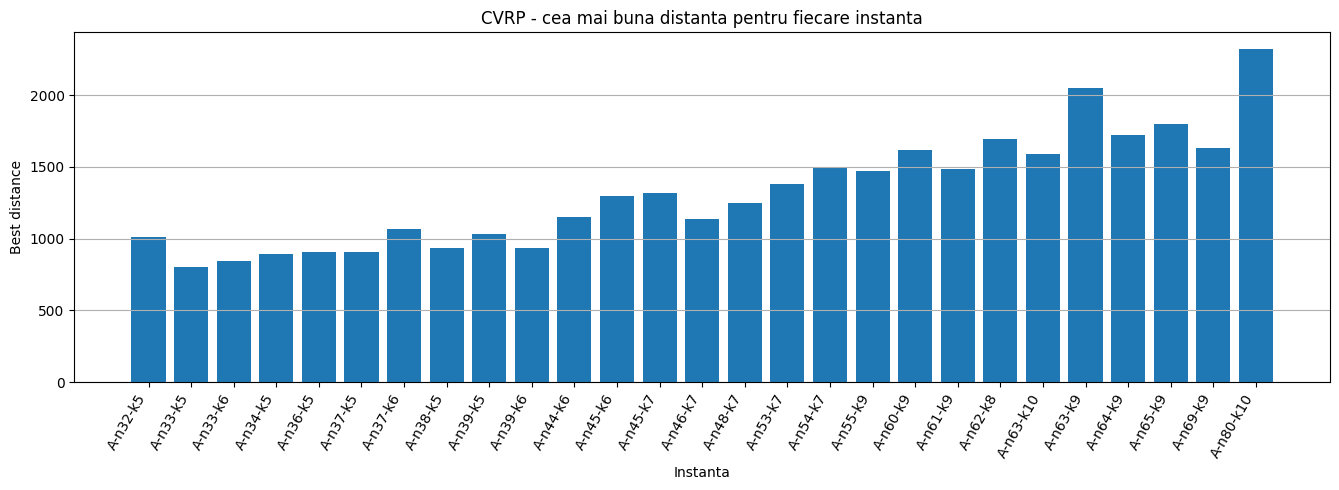

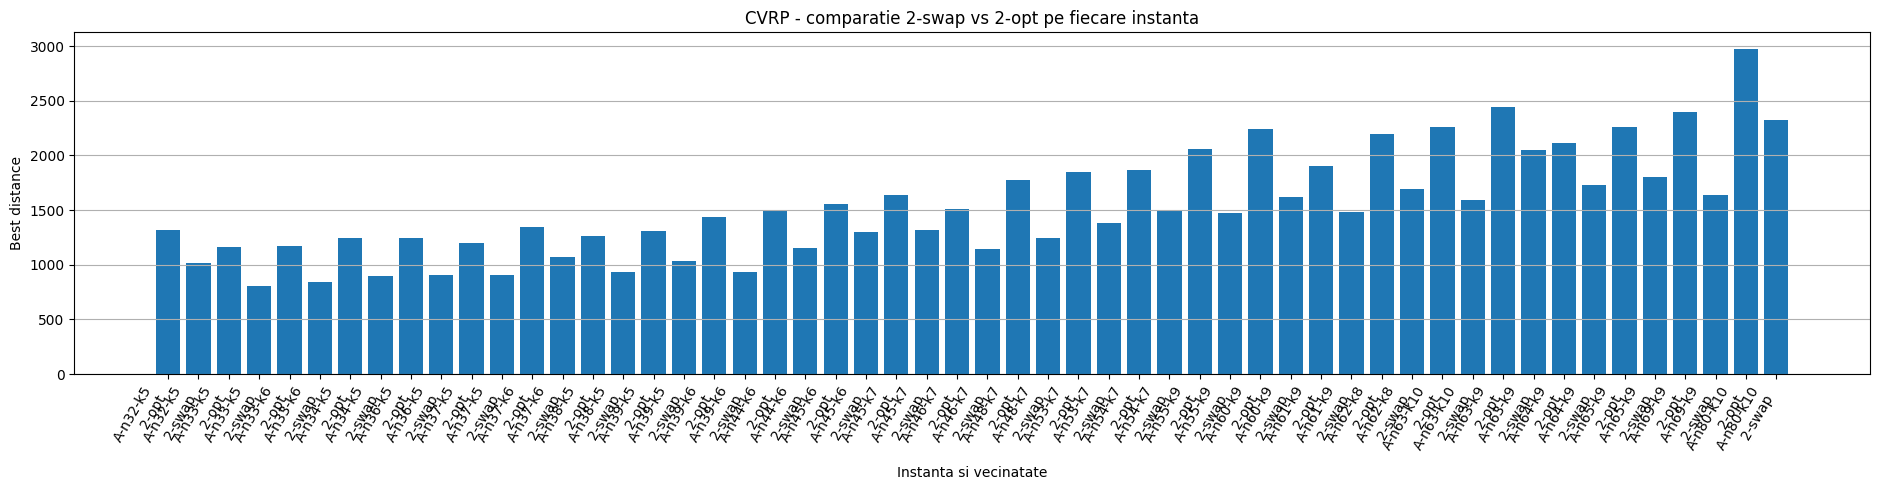

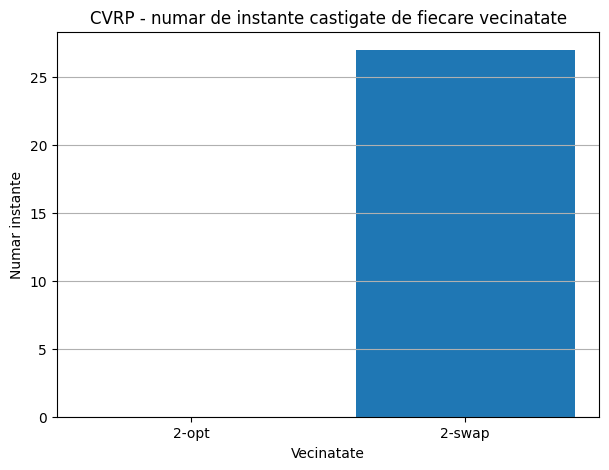

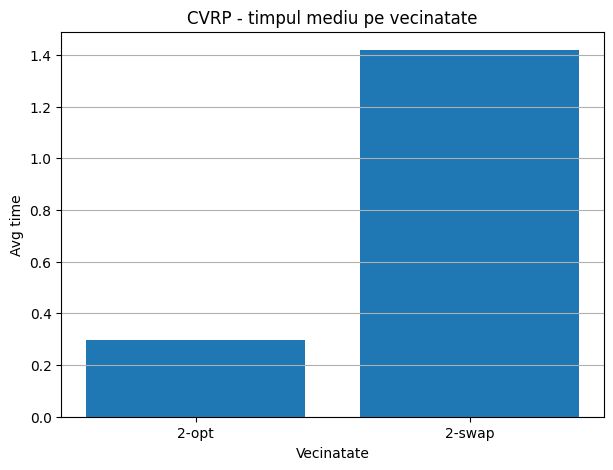

Instanta aleasa pentru graficele de detaliu: A-n33-k5
Vecinatate: 2-swap
Best distance: 802.063152014219
Solutia: [[17, 4, 10, 18, 16], [28, 26, 31, 11, 23], [13, 6, 27, 5, 29, 32, 19], [24, 30, 2, 22, 15, 20, 7, 25, 12], [3, 33, 14, 9, 8, 21]]


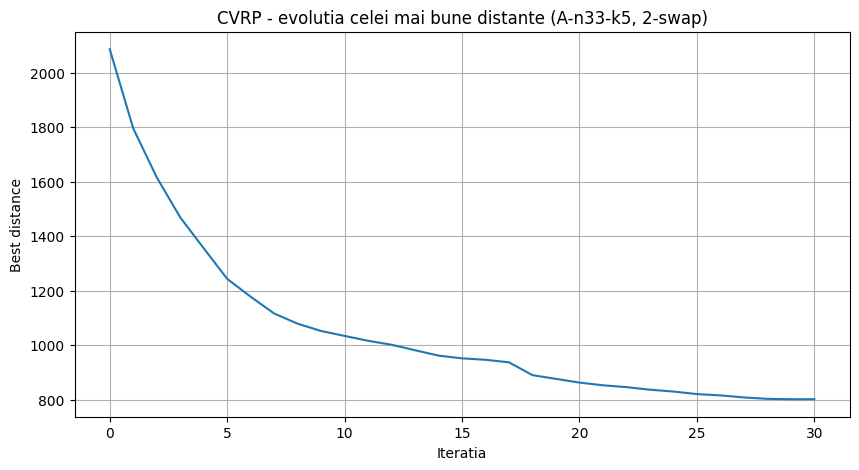

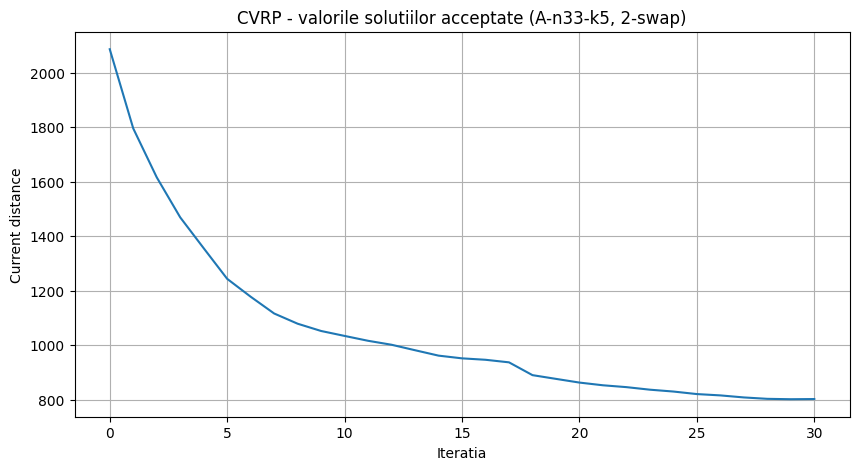

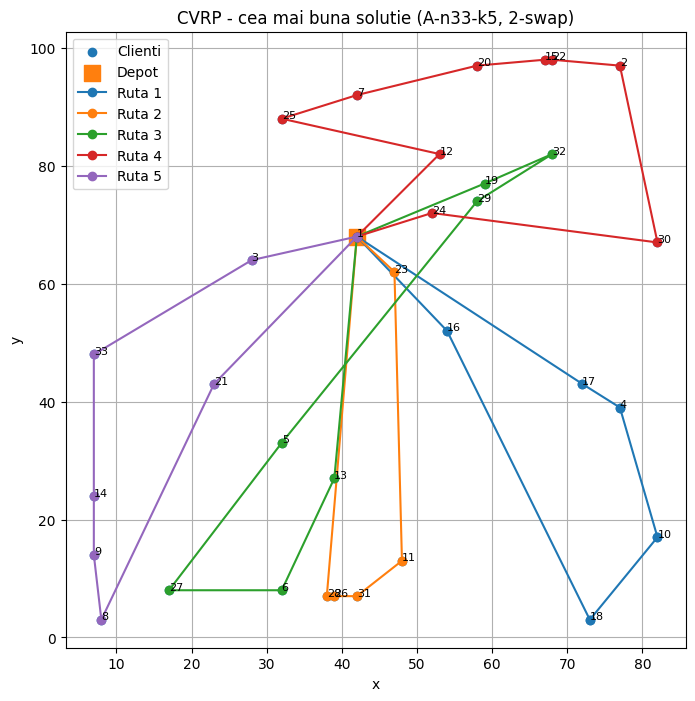

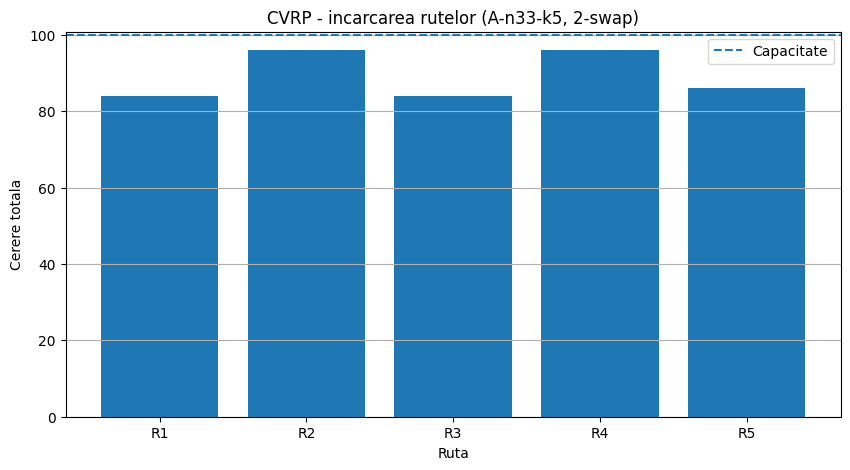

In [10]:
plot_best_distance_per_instance(experiment_rows)
plot_best_distance_by_neighborhood(experiment_rows)
plot_neighborhood_wins(experiment_rows)
plot_average_time_by_neighborhood(experiment_rows)

# Pentru evolutia cautarii si desenarea rutelor alegem automat instanta cu cea mai buna configuratie din tabel.
# Acest grafic este mai clar pentru o singura instanta decat pentru toate instantele simultan.
best_overall_row = min(best_rows_per_instance(experiment_rows), key=lambda row: row["best_fitness"])

instance_name = best_overall_row["pi"]
instance = instances[instance_name]
capacity = instance["capacity"]
coords = instance["coords"]
demands = instance["demands"]
depot = instance["depot"]

best_solution = best_overall_row["best_solution"]
best_history = best_overall_row["best_history"]
found_solutions = best_overall_row["found_solutions"]
best_neighborhood = best_overall_row["neighborhood"]

print("Instanta aleasa pentru graficele de detaliu:", instance_name)
print("Vecinatate:", best_neighborhood)
print("Best distance:", best_overall_row["best_fitness"])
print("Solutia:", best_solution)

plot_history(
    best_history,
    f"CVRP - evolutia celei mai bune distante ({instance_name}, {best_neighborhood})",
    "Best distance"
)

plot_history(
    found_solutions,
    f"CVRP - valorile solutiilor acceptate ({instance_name}, {best_neighborhood})",
    "Current distance"
)

plot_solution_CVRP(
    best_solution,
    coords,
    depot,
    f"CVRP - cea mai buna solutie ({instance_name}, {best_neighborhood})"
)

plot_route_loads_CVRP(
    best_solution,
    demands,
    capacity,
    f"CVRP - incarcarea rutelor ({instance_name}, {best_neighborhood})"
)


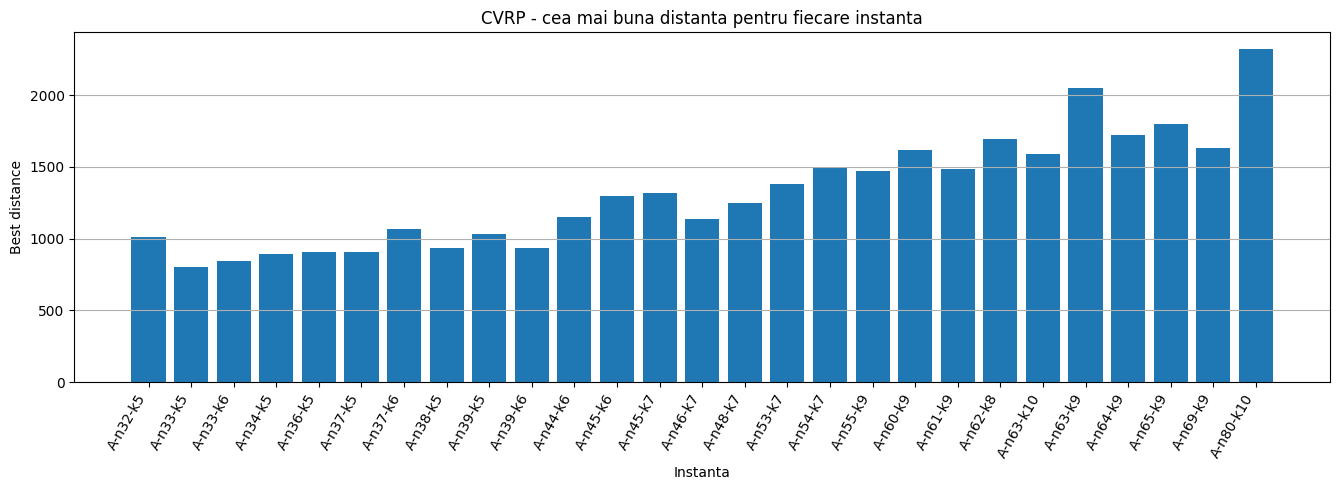

**Concluzie:**  
Graficul arată cea mai bună distanță obținută pentru fiecare instanță. Se observă că instanțele mai mari au, în general, distanțe totale mai mari, deoarece conțin mai mulți clienți și mai multe rute. Valorile cresc de la instanțele mici, cum ar fi `A-n32-k5`, spre instanțele mari, cum ar fi `A-n80-k10`.

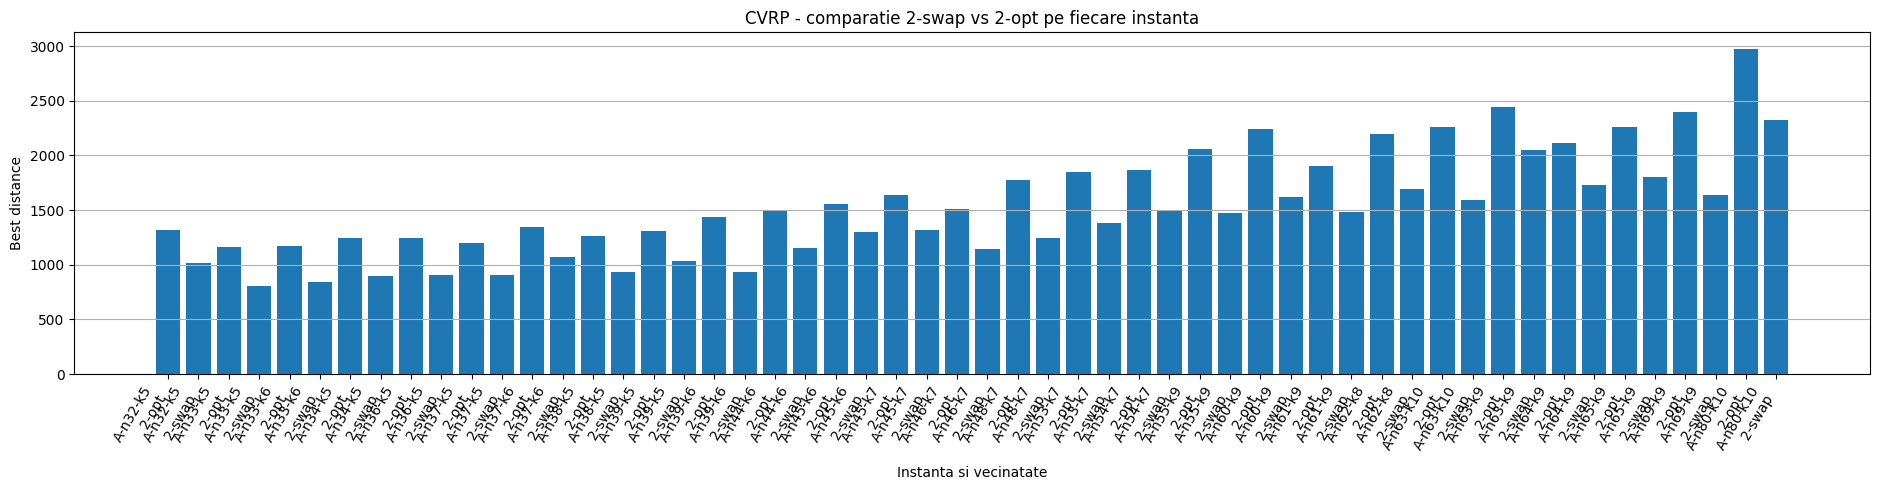

**Concluzie:**  
Graficul compară direct cele două vecinătăți pentru fiecare instanță. Pentru toate instanțele, barele corespunzătoare lui `2-swap` sunt mai mici decât cele pentru `2-opt`, ceea ce confirmă că `2-swap` găsește soluții cu distanță totală mai mică. Acest lucru se explică prin faptul că `2-swap` poate schimba clienți între rute, în timp ce `2-opt` modifică doar ordinea clienților într-o rută.

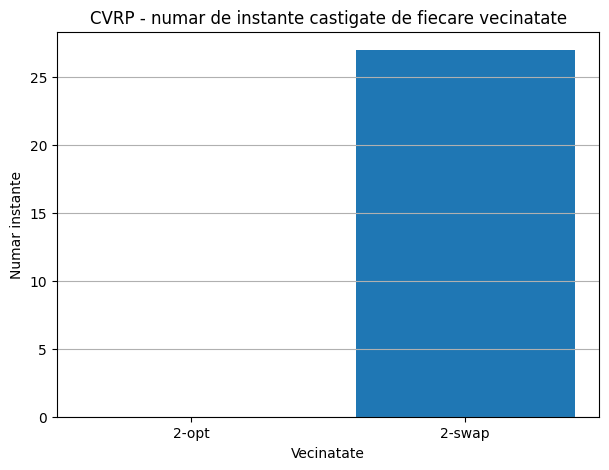

**Concluzie:**  
Graficul arată că `2-swap` câștigă toate cele 27 de instanțe, iar `2-opt` nu câștigă nicio instanță. Prin urmare, pentru datele testate, `2-swap` este vecinătatea mai eficientă din punctul de vedere al distanței obținute.

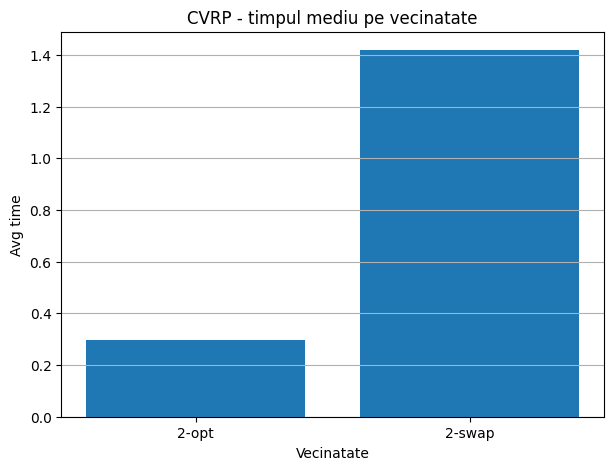

**Concluzie:**  
Graficul arată că `2-opt` are un timp mediu de execuție mai mic decât `2-swap`. Acest lucru este normal, deoarece `2-opt` lucrează în interiorul unei singure rute, în timp ce `2-swap` explorează schimburi între clienți care pot aparține unor rute diferite. Totuși, deși `2-swap` este mai lent, acesta produce soluții mai bune.

Instanta aleasa pentru graficele mai în detaliu: A-n33-k5  
Vecinatate: 2-swap  
Best distance: 802.063152014219  
Solutia: [[17, 4, 10, 18, 16], [28, 26, 31, 11, 23], [13, 6, 27, 5, 29, 32, 19], [24, 30, 2, 22, 15, 20, 7, 25, 12], [3, 33, 14, 9, 8, 21]]

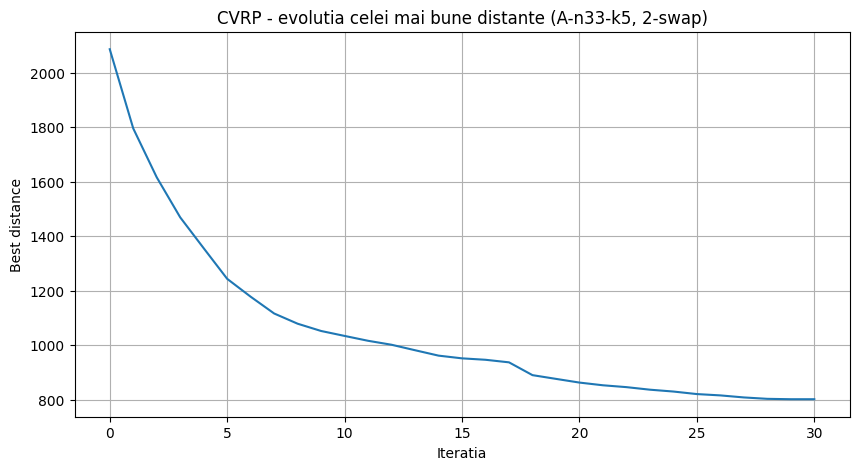

**Concluzie:**  
Graficul arată cum se îmbunătățește cea mai bună soluție pe parcursul iterațiilor. Curba scade atunci când algoritmul găsește o soluție mai bună și rămâne constantă atunci când nu se găsește o îmbunătățire. Zonele constante arată că algoritmul continuă să exploreze vecini, dar fără să îmbunătățească momentan cea mai bună soluție.

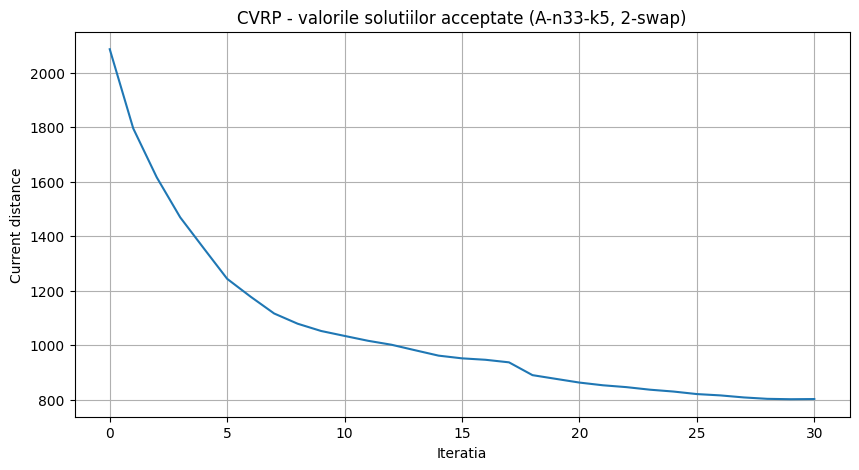

**Concluzie:**  
Graficul arată valorile soluțiilor acceptate la fiecare pas al algoritmului. Spre deosebire de graficul pentru cea mai bună distanță, aici valorile pot să crească sau să scadă, deoarece Tabu Search poate accepta și soluții mai slabe temporar pentru a evita blocarea într-un optim local.

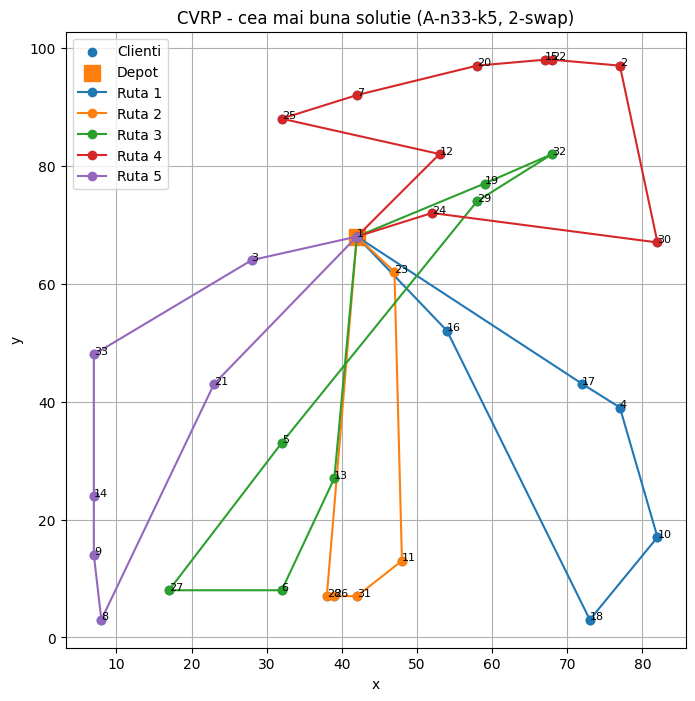

**Concluzie:**  
Graficul reprezintă rutele obținute pentru cea mai bună soluție. Se observă că fiecare rută pornește din depozit, vizitează un grup de clienți și se întoarce în depozit.

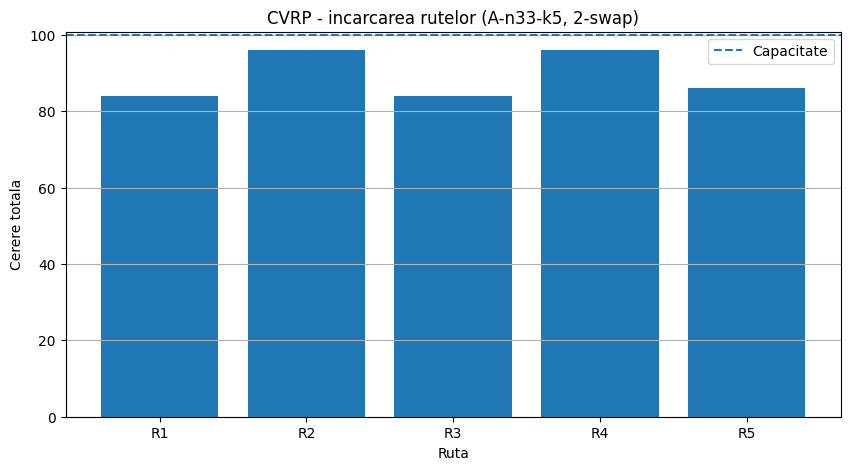

**Concluzie:**  
Graficul arată încărcarea fiecărei rute în raport cu capacitatea maximă a vehiculului. Toate barele sunt sub sau cel mult egale cu linia capacității, deci soluția este validă. Dacă unele rute sunt aproape de capacitate, înseamnă că vehiculele sunt folosite eficient.

**Concluzie finală TS:**  
În urma experimentelor pe toate instanțele din setul A-VRP, algoritmul Tabu Search a obținut cele mai bune rezultate folosind vecinătatea `2-swap`. Aceasta a câștigat toate cele 27 de instanțe, având o distanță medie mai mică decât `2-opt`. Totuși, `2-opt` a fost mai rapid, deci există un compromis între calitatea soluției și timpul de execuție. Pentru acest proiect, `2-swap` este varianta mai potrivită dacă obiectivul principal este minimizarea distanței totale, iar `2-opt` poate fi folosit când se dorește o rulare mai rapidă.  
Rezultatele pot varia ușor la o nouă rulare, deoarece soluția inițială este generată aleator. De aceea, fiecare configurație a fost rulată de mai multe ori, iar în tabel apar valorile `Best`, `Average` și `Worst`.  
**Influența instanțelor asupra rezultatelor:**  
Rezultatele diferă de la o instanță la alta deoarece fiecare instanță CVRP are o structură diferită: număr diferit de clienți, număr diferit de vehicule, cereri diferite și poziții diferite ale clienților. Instanțele mai mici, cum ar fi `A-n32-k5`, au în general distanțe totale mai mici și timp de execuție mai redus. Instanțele mai mari, cum ar fi `A-n69-k9` sau `A-n80-k10`, au mai mulți clienți și mai multe rute, deci spațiul de căutare este mai mare, iar distanțele obținute și timpul de rulare cresc.